# PCA + KMeans Unsupervised Learning Demo

## Demo 1: Standard Encoding (Frequency + One-Hot) - Hyperparameter Tuning

This notebook extends the base Demo 1 notebook by adding **SageMaker Hyperparameter Tuning** to the KMeans clustering step. Instead of manually training KMeans models with different K values and comparing Elbow Plots and Silhouette Scores, we use SageMaker's Automatic Model Tuning to systematically optimize KMeans training hyperparameters.

**What is different from the base Demo 1 notebook:**
- Steps 1-8 are identical (data loading, preprocessing, PCA)
- Step 10 determines optimal K via Silhouette Score analysis
- Step 11 uses SageMaker Hyperparameter Tuning to optimize training for that K
- Step 12 analyzes the tuning results
- Steps 13-16 are adapted to use the best tuned model

**Prerequisites:** Run the base Demo 1 notebook first to understand the manual approach. This notebook builds on that foundation.

**Encoding strategy:** Frequency encoding for rare categories + one-hot encoding for categorical features, producing ~200 sparse features. This is the same encoding as the base Demo 1 notebook.

**Compare with Demo 2 HPT:** Demo 2 uses optimized encoding (~74 dense features) with the same HPT approach. Running both shows how encoding choices affect tuning results.

# STEP 1: IMPORT LIBRARIES AND SETUP

Before we begin, we need to load all the Python libraries and tools this notebook uses. This cell installs any missing packages and imports everything we need.

**What is about to happen:**
- Install `mxnet` (for reading SageMaker model artifacts), `seaborn` (for plots), and `tabulate` (for formatted tables)
- Import AWS SageMaker SDK and Boto3 for cloud ML services
- Import pandas, NumPy, matplotlib, and scikit-learn for data handling and preprocessing
- Apply a compatibility patch so mxnet works with the current NumPy version
- Define a helper function (`load_model_array`) for reading SageMaker model files

In [1]:
# Install required libraries not included in the conda_python3 kernel
!pip install mxnet==1.9.1 seaborn tabulate

# AWS SageMaker and Boto3
import sagemaker
from sagemaker import get_execution_role
from sagemaker.image_uris import retrieve
from sagemaker.model import Model
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
import boto3
from botocore.exceptions import ClientError

# Data Manipulation
import pandas as pd
import numpy as np

# Patch: mxnet 1.9.1 uses np.bool which was removed in NumPy 1.24+
# This restores the alias so mxnet can import without errors
np.bool = np.bool_

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Additional Libraries
import tarfile
import mxnet as mx
import json
import time
from tabulate import tabulate

def load_model_array(filepath):
    """Load an MXNet model artifact and return the first array as NumPy.

    mx.ndarray.load may return a list or a dict depending on how the
    model was saved. This helper handles both cases.
    """
    loaded = mx.ndarray.load(filepath)
    if isinstance(loaded, dict):
        arr = list(loaded.values())[0].asnumpy()
    else:
        arr = loaded[0].asnumpy()
    return arr

print("All libraries imported successfully!")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
All libraries imported successfully!


## What to Look For

You should see **"All libraries imported successfully!"** with no errors. If you see a red error message, check that you are running this notebook on a SageMaker instance with the `conda_python3` kernel selected.

The `pip install` line may show some output about packages already being satisfied. That is normal.

# STEP 2: SAGEMAKER SETUP AND CONFIGURATION

This step connects the notebook to AWS services. It retrieves your IAM role (permissions), identifies which AWS region you are in, and looks up the Docker container images that SageMaker uses to run PCA and KMeans algorithms.

**What is about to happen:**
- Create a SageMaker session and retrieve your IAM execution role
- Identify the AWS region and default S3 bucket for storing data and models
- Look up the Docker image URIs for the PCA and KMeans built-in algorithms
- Create Boto3 clients for direct S3 and SageMaker API calls

In [2]:
def setup_sagemaker():
    """
    Initialize the SageMaker session, IAM role, AWS region, and service clients.
    Retrieve the Docker image URIs for both the PCA and KMeans algorithms.
    Configure the S3 bucket and prefix for storing data and model artifacts.

    Returns:
        dict: A dictionary containing all SageMaker configuration values.
    """
    # Initialize a SageMaker Session
    sagemaker_session = sagemaker.Session()

    # Retrieve the IAM role for SageMaker to access AWS resources
    role = get_execution_role()

    # Identify the AWS Region
    region = sagemaker_session.boto_region_name

    # Create Boto3 clients for S3 and SageMaker
    s3_client = boto3.client('s3')
    sagemaker_client = boto3.client('sagemaker')

    # Retrieve Docker image URIs for both algorithms
    pca_image_uri = retrieve('pca', region)
    kmeans_image_uri = retrieve('kmeans', region)

    # Define the default S3 bucket and prefix
    bucket = sagemaker_session.default_bucket()
    prefix = 'sagemaker/ames/pca-kmeans-demo1'

    print("Execution Role ARN:", role)
    print("AWS Region:", region)
    print("S3 Bucket:", bucket)
    print("S3 Prefix:", prefix)
    print("PCA Image URI:", pca_image_uri)
    print("KMeans Image URI:", kmeans_image_uri)

    return {
        'sagemaker_session': sagemaker_session,
        'role': role,
        'region': region,
        's3_client': s3_client,
        'sagemaker_client': sagemaker_client,
        'pca_image_uri': pca_image_uri,
        'kmeans_image_uri': kmeans_image_uri,
        'bucket': bucket,
        'prefix': prefix
    }


config = setup_sagemaker()

# Unpack for convenience throughout the notebook
sagemaker_session = config['sagemaker_session']
role = config['role']
region = config['region']
s3_client = config['s3_client']
sagemaker_client = config['sagemaker_client']
pca_image_uri = config['pca_image_uri']
kmeans_image_uri = config['kmeans_image_uri']
bucket = config['bucket']
prefix = config['prefix']

Execution Role ARN: arn:aws:iam::558253628403:role/LabRole
AWS Region: us-east-1
S3 Bucket: sagemaker-us-east-1-558253628403
S3 Prefix: sagemaker/ames/pca-kmeans-demo1
PCA Image URI: 382416733822.dkr.ecr.us-east-1.amazonaws.com/pca:1
KMeans Image URI: 382416733822.dkr.ecr.us-east-1.amazonaws.com/kmeans:1


## What to Look For

You should see your IAM Role ARN, AWS Region, S3 Bucket name, and the Docker image URIs for both PCA and KMeans. These values confirm that your notebook is properly connected to AWS.

- **Role ARN** should contain `LabRole` (AWS Academy) or a custom SageMaker role
- **Region** is typically `us-east-1` for Learner Lab accounts
- **S3 Bucket** is automatically created by SageMaker (e.g., `sagemaker-us-east-1-123456789`)

# STEP 3: LOAD AND EXPLORE THE DATASET

We load the same Ames Housing dataset used in the Linear Learner labs. This dataset contains 2,930 homes with 82 columns describing various features of residential properties in Ames, Iowa.

**What is about to happen:**
- Load `AmesHousing.csv` into a pandas DataFrame
- Display the shape (rows x columns), data types, and first 5 rows
- Show descriptive statistics for all numeric columns
- List any columns that have missing values

**Note:** We use `keep_default_na=False` to prevent pandas from treating the string `"None"` as a missing value. In this dataset, `"None"` is a valid category (e.g., Masonry Veneer Type = None means no masonry veneer). The string `"NA"` is still treated as missing (e.g., no basement).

In [3]:
def load_and_explore(filepath):
    """
    Load the Ames Housing dataset from a CSV file and display basic information
    about its shape, data types, and missing values.

    The dataset contains 2,930 homes with 82 columns describing various features
    of residential properties in Ames, Iowa. We use keep_default_na=False to
    prevent the string 'None' (a valid category for some features) from being
    treated as NaN.

    Parameters:
        filepath (str): The path to the CSV file.

    Returns:
        pd.DataFrame: The loaded DataFrame.
    """
    df = pd.read_csv(filepath, keep_default_na=False, na_values=['', 'NA'])

    print("Data loaded successfully!")
    print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"\nColumn data types:")
    print(df.dtypes.value_counts())
    print(f"\nFirst 5 rows:")
    display(df.head())
    print(f"\nDescriptive statistics (numeric columns):")
    display(df.describe())

    # Show columns with missing values
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        print(f"\nColumns with missing values ({len(missing)} columns):")
        print(missing)
    else:
        print("\nNo missing values found.")

    return df


df = load_and_explore('BankChurners.csv')

Data loaded successfully!

Shape: 10127 rows x 23 columns

Column data types:
int64      10
float64     7
object      6
Name: count, dtype: int64

First 5 rows:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998



Descriptive statistics (numeric columns):


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990



No missing values found.


## What to Look For

- **Shape:** 2,930 rows x 82 columns. Each row is one home, each column is a property feature.
- **Data types:** You should see a mix of `int64` (whole numbers like Year Built), `float64` (decimals like Lot Frontage), and `object` (text/categories like Neighborhood).
- **Missing values:** Several columns have missing data. Columns like `Alley`, `Pool QC`, and `Fence` have the most missing values because most homes simply do not have those features.
- **Descriptive statistics:** Look at the range of `SalePrice` (our validation variable). Most homes sell between $100K and $250K, with a few outliers above $600K.

# STEP 4: PREPROCESS THE DATA

This step performs the full data wrangling pipeline to prepare the Ames Housing data for unsupervised learning. We use the **same encoding approach as the Data Preparation Lab**: frequency encoding for high-cardinality categoricals and one-hot encoding for the rest.

The key difference from supervised learning: **SalePrice is NOT used as a feature**. We separate it and hold it aside so we can later validate whether our clusters are meaningful.

**What is about to happen:**
1. Drop index columns (`Order`, `PID`) that have no predictive value
2. Separate `SalePrice` into its own variable for later validation
3. Drop columns with more than 30% missing data (e.g., `Alley`, `Pool QC`, `Fence`)
4. Fill remaining missing values (numeric columns get the median, categorical columns get `"Missing"`)
5. Remove outliers where `Gr Liv Area` >= 4,000 sq ft (rare, extreme homes that could distort clusters)
6. Encode categorical variables:
   - **Frequency encoding** for columns with more than 10 unique categories (e.g., Neighborhood): each category is replaced by its proportion in the dataset
   - **One-hot encoding** for columns with 10 or fewer categories: creates binary (0/1) columns for each category
7. Save the preprocessed data

**Expected result:** Approximately **200 features**. Most of the feature count comes from one-hot encoding, which creates a separate column for every category minus one.

In [4]:
def preprocess_data(dataframe):
    """
    Apply the full preprocessing pipeline to the Ames Housing dataset for
    unsupervised learning. SalePrice is separated out (not used as a feature)
    and returned separately for cluster validation later.

    Pipeline steps:
        1. Drop Order and PID (index columns with no predictive value)
        2. Separate SalePrice into its own Series
        3. Drop columns with >30% missing data
        4. Fill missing numeric values with median, categorical with 'Missing'
        5. Remove outliers where Gr Liv Area >= 4000
        6. Encode categoricals (frequency for >10 unique, one-hot for the rest)
        7. Print summary of final feature set

    Parameters:
        dataframe (pd.DataFrame): The raw Ames Housing DataFrame.

    Returns:
        tuple: (features_df, sale_price_series) where features_df is the fully
               preprocessed DataFrame and sale_price_series is the held-out
               SalePrice values aligned by index.
    """
    df = dataframe.copy()
    print(f"Starting shape: {df.shape}")

    # 1. Drop ID and Naive Bayes classifier columns
    cols_to_drop = [col for col in df.columns if col.startswith('Naive_Bayes')]
    cols_to_drop.append('CLIENTNUM')
    if 'Unnamed: 0' in df.columns:
        cols_to_drop.append('Unnamed: 0')
    
    print(f"\n1. Dropping ID and Naive Bayes columns: {cols_to_drop}")
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    print(f"   Shape after dropping: {df.shape}")

    # 3. Drop columns with >30% missing data
    missing_fraction = df.isnull().mean()
    cols_to_drop = missing_fraction[missing_fraction > 0.3].index.tolist()
    print(f"\n3. Columns with >30% missing data: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"   Shape after dropping: {df.shape}")

    # 4. Fill remaining missing values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns

    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna('Missing')

    print(f"\n4. Filled missing values. Remaining nulls: {df.isnull().sum().sum()}")

    # 6. Encode categorical variables
    cat_cols = df.select_dtypes(include=['object']).columns
    freq_threshold = 10

    freq_encoded_cols = []
    one_hot_cols = []
    one_hot_frames = []
    freq_frames = {}

    for col in cat_cols:
        unique_count = df[col].nunique()
        if unique_count > freq_threshold:
            # Frequency encoding for high-cardinality columns
            freq_map = df[col].value_counts(normalize=True)
            freq_frames[col + '_freq'] = df[col].map(freq_map)
            freq_encoded_cols.append(col)
        else:
            # One-hot encoding for low-cardinality columns
            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
            one_hot_frames.append(dummies)
            one_hot_cols.append(col)

    # Merge frequency-encoded columns
    if freq_frames:
        freq_df = pd.DataFrame(freq_frames, index=df.index)
        df = pd.concat([df, freq_df], axis=1)

    # Merge one-hot-encoded columns
    if one_hot_frames:
        ohe_df = pd.concat(one_hot_frames, axis=1)
        df = pd.concat([df, ohe_df], axis=1)

    # Drop original categorical columns
    df.drop(columns=cat_cols, inplace=True)

    print(f"\n6. Categorical encoding complete:")
    if freq_encoded_cols:
        print(f"   Frequency-encoded (>{freq_threshold} unique): {freq_encoded_cols}")
    if one_hot_cols:
        print(f"   One-hot-encoded (<={freq_threshold} unique): {one_hot_cols}")

    # Reset index for clean alignment
    df = df.reset_index(drop=True)

    print(f"\nFinal preprocessed feature count: {df.shape[1]} features")
    print(f"Final row count: {df.shape[0]} customers")

    # 7. Save preprocessed data
    df.to_csv('BankChurners_preprocessed.csv', index=False)
    print(f"\n7. Saved preprocessed data to BankChurners_preprocessed.csv")

    return df


df_features = preprocess_data(df)
print(f"\nFeature columns: {list(df_features.columns[:10])} ... ({df_features.shape[1]} total)")

Starting shape: (10127, 23)

1. Dropping ID and Naive Bayes columns: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', 'CLIENTNUM']
   Shape after dropping: (10127, 20)

3. Columns with >30% missing data: []
   Shape after dropping: (10127, 20)

4. Filled missing values. Remaining nulls: 0

6. Categorical encoding complete:
   One-hot-encoded (<=10 unique): ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

Final preprocessed feature count: 33 features
Final row count: 10127 customers

7. Saved preprocessed data to BankChurners_preprocessed.csv

Feature columns: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revo

## What to Look For

Review the output to understand how preprocessing changed the data:

- **Starting shape:** 2,930 rows x 82 columns (the raw data)
- **After dropping columns:** About 5 columns should be dropped for having >30% missing data (Alley, Fireplace Qu, Pool QC, Fence, Misc Feature)
- **After dropping outliers:** A few rows are removed (homes with >4,000 sq ft living area)
- **Encoding summary:** Look at which columns were frequency-encoded vs. one-hot encoded
- **Final feature count:** Approximately **200 features**. This large number comes from one-hot encoding creating many sparse binary columns.

**Key takeaway for this demo:** The standard encoding approach produces a lot of features, many of which are sparse (mostly zeros). When we run PCA in later steps, watch for how this affects the Scree Plot and feature loadings. The large number of sparse features can make it harder for PCA to find clean patterns.

# STEP 5: STANDARDIZE FEATURES

PCA is a **variance-based** algorithm. It finds the directions (principal components) that capture the most variance in the data. If features have vastly different scales (for example, `Gr Liv Area` ranges from 300 to 5,000 while `Overall Qual` ranges from 1 to 10), PCA will be dominated by the large-scale features.

**StandardScaler** transforms each feature to have mean = 0 and standard deviation = 1, ensuring all features contribute equally to the principal components.

**What is about to happen:**
- Apply StandardScaler to all preprocessed features
- Show before/after mean and standard deviation for the first 5 features
- Convert to float32 format for SageMaker compatibility

In [5]:
def standardize_features(features_df):
    """
    Apply StandardScaler to all features so that each has mean=0 and std=1.
    This is critical for PCA because it is a variance-based algorithm.
    Without standardization, features with larger numeric ranges would
    dominate the principal components.

    Parameters:
        features_df (pd.DataFrame): The preprocessed feature DataFrame.

    Returns:
        tuple: (scaled_array, scaler, feature_names) where scaled_array is a
               float32 NumPy array, scaler is the fitted StandardScaler, and
               feature_names is the list of column names.
    """
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(features_df)

    # Convert to float32 for SageMaker compatibility
    scaled_data = scaled_data.astype('float32')

    feature_names = list(features_df.columns)

    print(f"Standardized {scaled_data.shape[1]} features for {scaled_data.shape[0]} samples")
    print(f"\nBefore standardization (first 5 features):")
    for col in features_df.columns[:5]:
        print(f"  {col}: mean={features_df[col].mean():.2f}, std={features_df[col].std():.2f}")

    print(f"\nAfter standardization (first 5 features):")
    for i, col in enumerate(features_df.columns[:5]):
        print(f"  {col}: mean={scaled_data[:, i].mean():.4f}, std={scaled_data[:, i].std():.4f}")

    return scaled_data, scaler, feature_names


scaled_data, scaler, feature_names = standardize_features(df_features)
num_features = scaled_data.shape[1]
print(f"\nTotal features for PCA input: {num_features}")

Standardized 33 features for 10127 samples

Before standardization (first 5 features):
  Customer_Age: mean=46.33, std=8.02
  Dependent_count: mean=2.35, std=1.30
  Months_on_book: mean=35.93, std=7.99
  Total_Relationship_Count: mean=3.81, std=1.55
  Months_Inactive_12_mon: mean=2.34, std=1.01

After standardization (first 5 features):
  Customer_Age: mean=-0.0000, std=1.0000
  Dependent_count: mean=0.0000, std=1.0000
  Months_on_book: mean=0.0000, std=1.0000
  Total_Relationship_Count: mean=0.0000, std=1.0000
  Months_Inactive_12_mon: mean=0.0000, std=1.0000

Total features for PCA input: 33


## What to Look For

- **Feature count:** Approximately 200 features have been standardized
- **Before standardization:** Each feature had its original scale (e.g., `Gr Liv Area` has mean ~1,500 and std ~500, while `Overall Qual` has mean ~6 and std ~1.4)
- **After standardization:** Every feature now has mean ~0.0000 and std ~1.0000. This puts all features on equal footing for PCA.

**Why this matters:** Without standardization, PCA would be dominated by features with large numeric ranges. Living area (measured in hundreds of square feet) would drown out quality ratings (measured in single digits). Standardization ensures that a 1-unit change in quality has the same weight as a 1-unit change in living area.

## Why PCA Before KMeans?

Our preprocessed dataset has approximately **200 features**. Running KMeans directly on 200 features creates two problems:

1. **The curse of dimensionality.** In high-dimensional space, the concept of "distance" breaks down. All data points become roughly equidistant from each other, which means KMeans cannot form meaningful clusters. Think of it this way: if you tried to sort 2,900 photos by comparing them across 200 attributes simultaneously, every photo would seem equally similar (or different) to every other photo.

2. **Visualization is impossible.** We cannot plot 200 dimensions. By reducing to 2 principal components, we can actually see the clusters on a scatter plot and validate whether they make sense.

**PCA solves both problems** by compressing those ~200 features into just 2-3 "summary dimensions" (principal components) that capture the most important patterns in the data. It is like replacing 200 survey questions with 2-3 key themes that explain most of the variation between respondents.

**Note:** With ~200 features (many of them sparse one-hot columns), PCA may need more components to capture a high percentage of variance. This is expected behavior with sparse data.

**Important:** Principal components are combinations of all original features, not individual features. PC1 might capture "overall home quality and size" while PC2 might capture "age vs. modernity." We will examine the actual feature loadings in STEP 8 to see what each component represents.

# STEP 6: TRAIN PCA MODELS

We train multiple PCA models with different numbers of components to determine how many principal components are needed to capture most of the variance. SageMaker PCA uses the built-in PCA algorithm, which runs as a distributed training job.

We use `wait=False` to train all models asynchronously (in parallel), then wait for each to complete.

**What is about to happen:**
- Launch 5 separate PCA training jobs on SageMaker (one for each component count: 2, 3, 5, 10, 20)
- All 5 jobs run in parallel to save time
- Each job takes under a minute on an `ml.m5.large` instance
- After training, the model artifacts are saved to S3

## PCA Hyperparameters

| Hyperparameter | Value | Why |
|----------------|-------|-----|
| `algorithm_mode` | `regular` | Exact PCA (not approximate). Fine for our dataset size (~2,900 rows). Use `randomized` for datasets with 100K+ rows. |
| `subtract_mean` | `False` | We already standardized the data in STEP 5 (mean=0, std=1), so subtracting the mean again would have no effect. |
| `feature_dim` | ~200 | Must match the number of input features exactly. SageMaker requires this to be set explicitly. |
| `num_components` | 2, 3, 5, 10, 20 | We train five models to compare how much variance different component counts capture. |

**Instance type:** `ml.m5.large` is the smallest general-purpose instance available in SageMaker. PCA on ~2,900 rows does not need a larger instance.

**Training jobs:** This step launches 5 PCA training jobs (one per component count), all running in parallel.

In [6]:
def train_pca_models(scaled_data, num_features, component_values, sagemaker_session, role, bucket, prefix, sagemaker_client):
    """
    Train SageMaker PCA models with different num_components values.
    Each model is trained asynchronously (wait=False) for efficiency.

    Uses sagemaker.PCA (the built-in algorithm class) which provides the
    record_set() method for converting NumPy arrays to RecordIO-protobuf
    format and uploading to S3 automatically.

    Parameters:
        scaled_data (np.ndarray): The standardized feature array (float32).
        num_features (int): The number of input features.
        component_values (list): List of num_components values to try.
        sagemaker_session: The SageMaker session.
        role (str): The IAM role ARN.
        bucket (str): The S3 bucket name.
        prefix (str): The S3 prefix.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        list: A list of (num_components, s3_model_uri) tuples.
    """
    output_path = f's3://{bucket}/{prefix}/pca/output'
    training_jobs = []

    # Timestamp ensures unique job names if the notebook is re-run
    timestamp = time.strftime('%Y%m%d-%H%M%S')

    for n_components in component_values:
        job_name = f'pca-ames-demo1-{n_components}comp-{timestamp}'

        pca_estimator = sagemaker.PCA(
            role=role,
            instance_count=1,
            instance_type='ml.m5.large',
            num_components=n_components,
            algorithm_mode='regular',
            subtract_mean=False,  # Already standardized
            output_path=output_path,
            sagemaker_session=sagemaker_session
        )

        # Create a RecordSet from the NumPy array and start training asynchronously
        record_set = pca_estimator.record_set(scaled_data, channel='train')
        pca_estimator.fit(record_set, wait=False, job_name=job_name)
        training_jobs.append((n_components, pca_estimator.latest_training_job.name))
        print(f"Started training job: {job_name} ({n_components} components)")

    # Wait for all training jobs to complete and collect model URIs
    print("\nWaiting for all PCA training jobs to complete...")
    pca_model_paths = []

    for n_components, job_name in training_jobs:
        sagemaker_client.get_waiter('training_job_completed_or_stopped').wait(TrainingJobName=job_name)
        job_description = sagemaker_client.describe_training_job(TrainingJobName=job_name)
        model_s3_uri = job_description['ModelArtifacts']['S3ModelArtifacts']
        pca_model_paths.append((n_components, model_s3_uri))
        print(f"  Completed: {job_name}")

    # Display results
    headers = ['Components', 'S3 Model Artifact Path']
    print(f"\n{tabulate(pca_model_paths, headers=headers)}")

    return pca_model_paths


component_values = [2, 3, 5, 10, 20]
pca_model_paths = train_pca_models(
    scaled_data, num_features, component_values,
    sagemaker_session, role, bucket, prefix,
    sagemaker_client
)

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-ames-demo1-2comp-20260321-024304


Started training job: pca-ames-demo1-2comp-20260321-024304 (2 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-ames-demo1-3comp-20260321-024304


Started training job: pca-ames-demo1-3comp-20260321-024304 (3 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-ames-demo1-5comp-20260321-024304


Started training job: pca-ames-demo1-5comp-20260321-024304 (5 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-ames-demo1-10comp-20260321-024304


Started training job: pca-ames-demo1-10comp-20260321-024304 (10 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-ames-demo1-20comp-20260321-024304


Started training job: pca-ames-demo1-20comp-20260321-024304 (20 components)

Waiting for all PCA training jobs to complete...
  Completed: pca-ames-demo1-2comp-20260321-024304
  Completed: pca-ames-demo1-3comp-20260321-024304
  Completed: pca-ames-demo1-5comp-20260321-024304
  Completed: pca-ames-demo1-10comp-20260321-024304
  Completed: pca-ames-demo1-20comp-20260321-024304

  Components  S3 Model Artifact Path
------------  ------------------------------------------------------------------------------------------------------------------------------------------
           2  s3://sagemaker-us-east-1-558253628403/sagemaker/ames/pca-kmeans-demo1/pca/output/pca-ames-demo1-2comp-20260321-024304/output/model.tar.gz
           3  s3://sagemaker-us-east-1-558253628403/sagemaker/ames/pca-kmeans-demo1/pca/output/pca-ames-demo1-3comp-20260321-024304/output/model.tar.gz
           5  s3://sagemaker-us-east-1-558253628403/sagemaker/ames/pca-kmeans-demo1/pca/output/pca-ames-demo1-5comp-20260321-02

## What to Look For

You should see 5 training jobs start, followed by a table showing each model's S3 artifact path. All jobs should complete within 1-2 minutes.

- Each job name includes the number of components and a timestamp (e.g., `pca-ames-demo1-2comp-20260303-143022`)
- The timestamp ensures you can re-run this step without name conflicts
- If any job fails, check the SageMaker console for error details (most common issue: insufficient instance quota)

# STEP 7: ANALYZE PCA RESULTS (SCREE PLOT)

A **Scree Plot** shows how much variance each principal component explains. This is the PCA equivalent of the Elbow Plot in KMeans. We also plot the **cumulative variance** to see how many components are needed to capture 80-90% of the total variance.

**What is about to happen:**
- Download the 20-component PCA model artifacts from S3
- Extract the component vectors and compute variance explained by each
- Create two side-by-side plots: individual variance (bar chart) and cumulative variance (line chart)
- Print the variance percentage for each component

**The teaching moment:** Can we really reduce ~200 features down to just 2-3 principal components while retaining most of the information?

Model artifact contents (/tmp/pca-20):
  model_algo-1['s']: shape (20,)
  model_algo-1['v']: shape (33, 20)
Using model_algo-1['s'] as singular values: shape (20,)

Using model_algo-1['v'] as component vectors: shape (33, 20)

Variance analysis (20 components):
Component    Variance %      Cumulative %   
------------------------------------------
PC1               10.63%         10.63%
PC2                7.09%         17.73%
PC3                5.88%         23.61%
PC4                5.53%         29.14%
PC5                4.89%         34.03%
PC6                4.27%         38.31%
PC7                4.15%         42.45%
PC8                3.98%         46.44%
PC9                3.82%         50.26%
PC10               3.69%         53.95%
PC11               3.57%         57.53%
PC12               3.52%         61.04%
PC13               3.44%         64.48%
PC14               3.29%         67.77%
PC15               3.26%         71.02%
PC16               3.22%         74.24%
PC17      

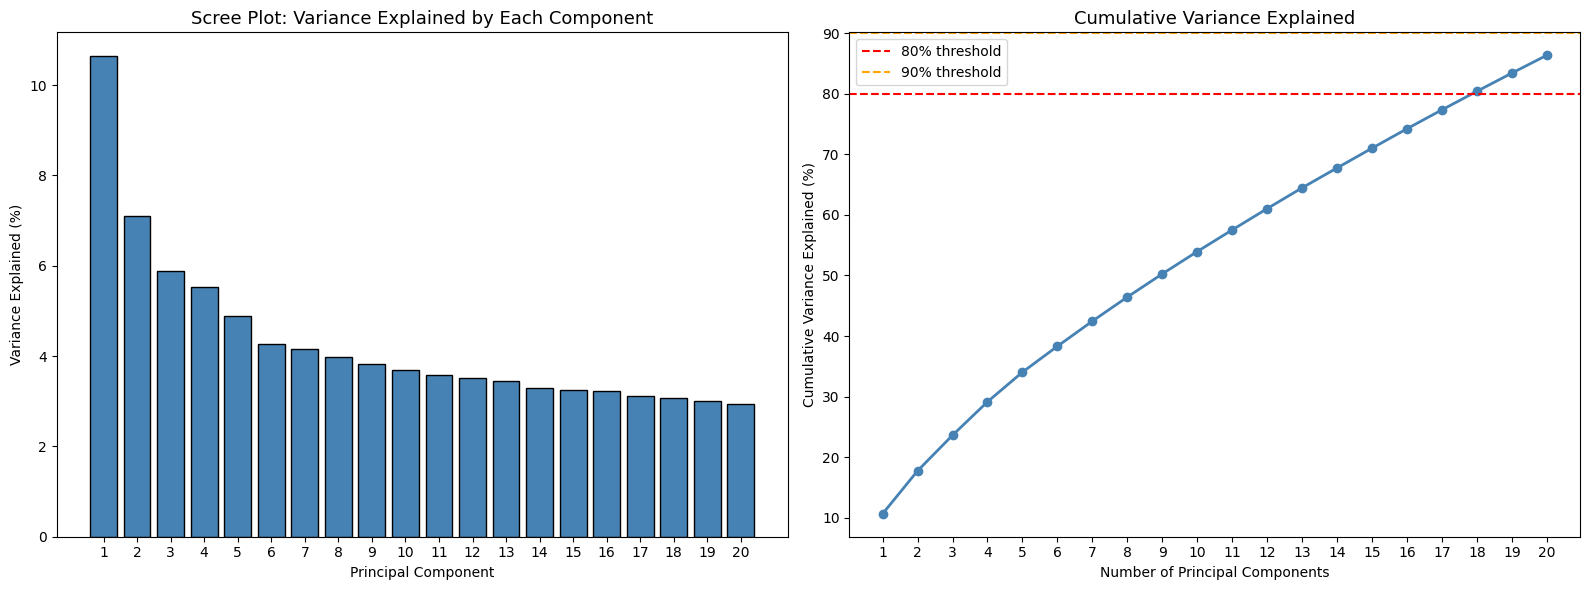


18 components capture 80.4% of the variance from 33 features


In [7]:
def analyze_pca_results(pca_model_paths, bucket, s3_client, scaled_data):
    """
    Download PCA model artifacts, discover the file structure, extract
    component vectors and singular values, and create Scree Plots.

    Parameters:
        pca_model_paths (list): List of (num_components, s3_uri) tuples.
        bucket (str): The S3 bucket name.
        s3_client: The Boto3 S3 client.
        scaled_data (np.ndarray): The standardized feature array for variance calculation.

    Returns:
        tuple: (explained_variance_ratio, cumulative_variance) arrays.
    """
    import os

    # Use the model with the most components for the Scree Plot
    max_components, max_model_path = max(pca_model_paths, key=lambda x: x[0])

    # Download and extract model artifacts
    local_path = f'/tmp/pca-model-{max_components}.tar.gz'
    s3_key = max_model_path.replace(f's3://{bucket}/', '')
    s3_client.download_file(bucket, s3_key, local_path)

    extract_dir = f'/tmp/pca-{max_components}'
    with tarfile.open(local_path) as tar:
        tar.extractall(path=extract_dir, filter='data')

    # Discover all files and their contents
    print(f"Model artifact contents ({extract_dir}):")
    all_arrays = {}
    for filename in sorted(os.listdir(extract_dir)):
        filepath = os.path.join(extract_dir, filename)
        if os.path.isfile(filepath):
            try:
                loaded = mx.ndarray.load(filepath)
                if isinstance(loaded, dict):
                    for key, val in loaded.items():
                        arr = val.asnumpy()
                        label = f"{filename}[\'{key}\']"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
                elif isinstance(loaded, list):
                    for i, val in enumerate(loaded):
                        arr = val.asnumpy()
                        label = f"{filename}[{i}]"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
            except Exception as e:
                print(f"  {filename}: could not load ({e})")

    # Find the component vectors: the 2D array with shape (num_components, num_features)
    # or (num_features, num_components)
    component_vectors = None
    singular_values = None
    num_features = scaled_data.shape[1]

    for label, arr in all_arrays.items():
        if arr.ndim == 2:
            if component_vectors is None:
                component_vectors = arr
                print(f"\nUsing {label} as component vectors: shape {arr.shape}")
        elif arr.ndim == 1 and len(arr) == max_components:
            singular_values = arr
            print(f"Using {label} as singular values: shape {arr.shape}")

    # If we found component vectors, compute variance from projections
    if component_vectors is not None:
        # Orient so we can do: scaled_data @ V = (n_samples, num_components)
        if component_vectors.shape[0] == num_features:
            V = component_vectors  # Already (num_features, num_components)
        else:
            V = component_vectors.T  # Transpose to (num_features, num_components)

        projected = scaled_data @ V
        variance_per_component = np.var(projected, axis=0)
        total_variance = np.sum(np.var(scaled_data, axis=0))
        explained_variance_ratio = variance_per_component / total_variance
        # Sort descending so PC1 = highest variance (SageMaker may return ascending order)
        sort_idx = np.argsort(explained_variance_ratio)[::-1]
        explained_variance_ratio = explained_variance_ratio[sort_idx]
        cumulative_variance = np.cumsum(explained_variance_ratio)

    elif singular_values is not None:
        # Fall back to singular values if no 2D matrix found
        print("\nNo 2D component matrix found. Using singular values for variance.")
        variance = singular_values ** 2
        total_variance = np.sum(variance)
        explained_variance_ratio = variance / total_variance
        # Sort descending so PC1 = highest variance (SageMaker may return ascending order)
        explained_variance_ratio = np.sort(explained_variance_ratio)[::-1]
        cumulative_variance = np.cumsum(explained_variance_ratio)

    else:
        raise ValueError("Could not find component vectors or singular values in model artifacts.")

    # Print variance summary
    n_components = len(explained_variance_ratio)
    print(f"\nVariance analysis ({n_components} components):")
    print(f"{'Component':<12} {'Variance %':<15} {'Cumulative %':<15}")
    print("-" * 42)
    for i in range(n_components):
        print(f"PC{i+1:<10} {explained_variance_ratio[i]*100:>10.2f}%    {cumulative_variance[i]*100:>10.2f}%")

    # Create Scree Plot and Cumulative Variance Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    components = range(1, n_components + 1)
    axes[0].bar(components, explained_variance_ratio * 100, color='steelblue', edgecolor='black')
    axes[0].set_title('Scree Plot: Variance Explained by Each Component', fontsize=13)
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Variance Explained (%)')
    axes[0].set_xticks(list(components))

    axes[1].plot(components, cumulative_variance * 100, marker='o', color='steelblue', linewidth=2)
    axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
    axes[1].axhline(y=90, color='orange', linestyle='--', label='90% threshold')
    axes[1].set_title('Cumulative Variance Explained', fontsize=13)
    axes[1].set_xlabel('Number of Principal Components')
    axes[1].set_ylabel('Cumulative Variance Explained (%)')
    axes[1].set_xticks(list(components))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return explained_variance_ratio, cumulative_variance


explained_variance_ratio, cumulative_variance = analyze_pca_results(
    pca_model_paths, bucket, s3_client, scaled_data
)

# Determine how many components capture at least 80% variance
for i, cv in enumerate(cumulative_variance):
    if cv >= 0.80:
        print(f"\n{i+1} components capture {cv*100:.1f}% of the variance from {num_features} features")
        break

## What to Look For

**Scree Plot (left):** The first few components should explain the most variance, with each subsequent component explaining less. With ~200 sparse features, the variance tends to be spread across many components, so PC1 may explain only 10-15% of the total variance.

**Cumulative Variance (right):** The red dashed line marks 80% and the orange line marks 90%. With sparse one-hot features, you may need many components to reach 80%. This is a known limitation of one-hot encoding for PCA.

**Key insight:** Even though 2 components may capture a modest percentage of total variance with ~200 sparse features, PCA is still valuable because it extracts the most important signal. The clusters may still be meaningful, just noisier than with denser features.

# STEP 8: TRANSFORM DATA USING PCA

Now we use our chosen PCA model to reduce the ~200 features down to a small number of principal components. We extract the principal component vectors from the model artifacts and apply the transformation locally using matrix multiplication:

**PCA-transformed data = Standardized data x Principal Component Vectors**

**What is about to happen:**
- Download the 2-component PCA model from S3
- Extract the principal component vectors (a matrix showing how each original feature contributes to each PC)
- Display the **top 10 feature loadings** for PC1 and PC2 as bar charts
- Apply the transformation: multiply our standardized data by the component vectors to get 2 PCA coordinates per home
- Plot all homes in 2D PCA space

For clustering visualization, we will use **2 components** (easy to plot in 2D). If the Scree Plot showed that 3 components capture significantly more variance, you could use 3 instead.

Model artifact contents (2 components):
  model_algo-1['s']: shape (2,)
  model_algo-1['v']: shape (33, 2)

Using model_algo-1['v'] as component vectors: shape (33, 2)
Principal components matrix shape: (33, 2) (features x components)

--- Top 10 Feature Loadings per Component ---
(Loadings show how much each original feature contributes to a component)

PC1 Top Loadings:
   1. Total_Trans_Ct                 -0.5412
   2. Total_Trans_Amt                -0.4910
   3. Attrition_Flag_Existing Customer -0.3470
   4. Total_Ct_Chng_Q4_Q1            -0.2215
   5. Total_Revolving_Bal            -0.2043
   6. Contacts_Count_12_mon          +0.2019
   7. Total_Relationship_Count       +0.1839
   8. Avg_Utilization_Ratio          -0.1561
   9. Customer_Age                   +0.1491
  10. Months_on_book                 +0.1438

PC2 Top Loadings:
   1. Avg_Open_To_Buy                +0.4851
   2. Credit_Limit                   +0.4787
   3. Gender_M                       +0.3460
   4. Avg_Utilizati

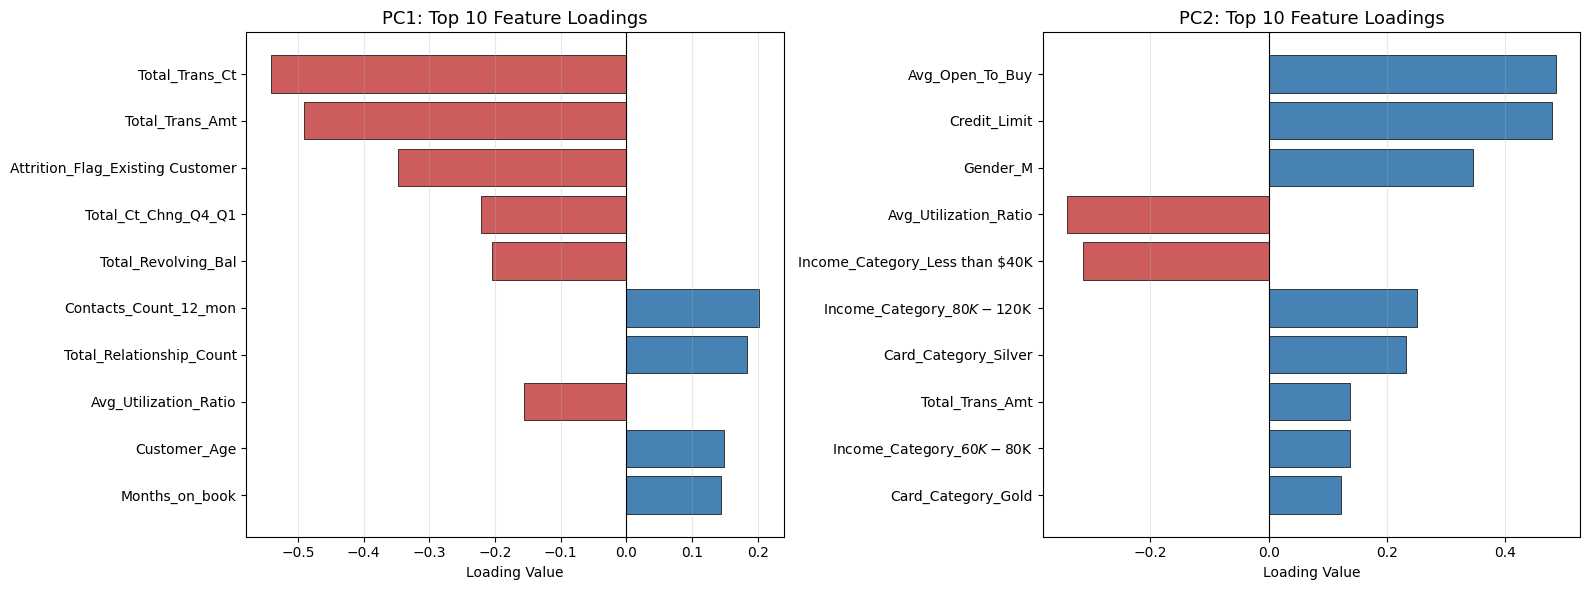


Blue bars = positive loading (feature pushes the component score higher)
Red bars = negative loading (feature pushes the component score lower)

PCA-transformed data shape: (10127, 2)
Reduced from 33 features to 2 principal components


,PC1,PC2
0,0.600175,1.233214
1,-2.431748,-0.983795
2,-0.659022,0.683708
3,-1.959256,-2.425627
4,-1.057192,0.507454


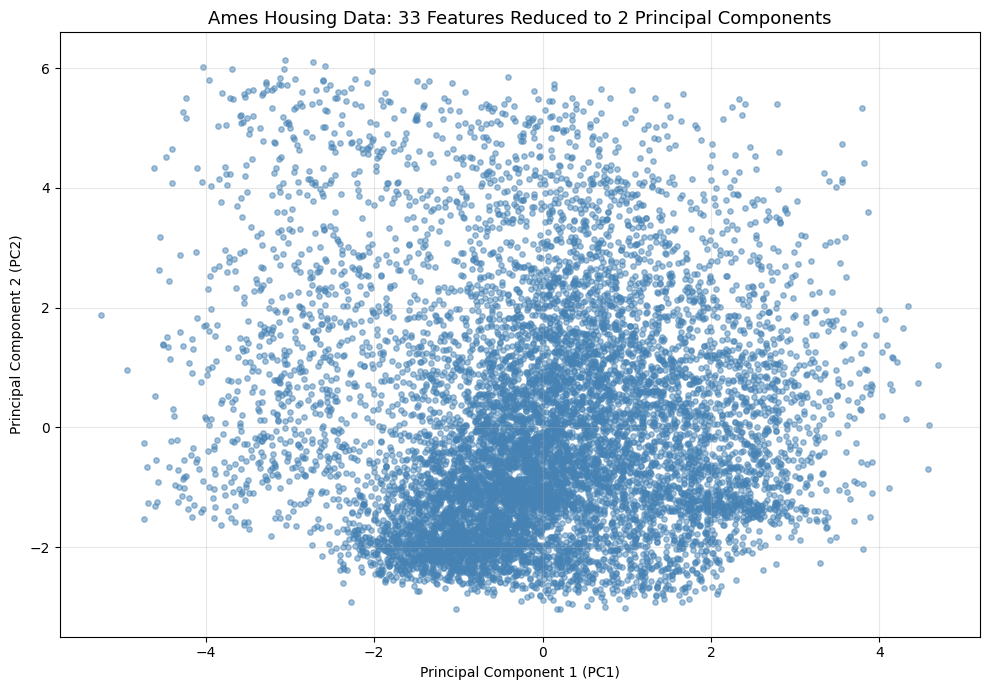

In [8]:
def transform_with_pca(scaled_data, pca_model_paths, bucket, s3_client, num_components_to_use=2, feature_names=None):
    """
    Extract principal component vectors from the trained PCA model and apply
    the transformation to reduce the dimensionality of the data. Also displays
    the top feature loadings for each principal component, showing which original
    features contribute most to each component.

    The transformation is a matrix multiplication:
        pca_data = standardized_data @ component_vectors.T

    Parameters:
        scaled_data (np.ndarray): The standardized feature array.
        pca_model_paths (list): List of (num_components, s3_uri) tuples.
        bucket (str): The S3 bucket name.
        s3_client: The Boto3 S3 client.
        num_components_to_use (int): Number of PCA components for the output.
        feature_names (list): Optional list of feature names for loading analysis.

    Returns:
        tuple: (pca_df, components_matrix) where pca_df is a DataFrame with
               columns PC1, PC2, etc. and components_matrix is the transformation
               matrix for reuse on new data.
    """
    import os

    # Find the model with the matching number of components
    model_path = next(path for n, path in pca_model_paths if n == num_components_to_use)

    # Download and extract model artifacts
    local_path = f'/tmp/pca-transform-{num_components_to_use}.tar.gz'
    s3_key = model_path.replace(f's3://{bucket}/', '')
    s3_client.download_file(bucket, s3_key, local_path)

    extract_dir = f'/tmp/pca-transform-{num_components_to_use}'
    with tarfile.open(local_path) as tar:
        tar.extractall(path=extract_dir, filter='data')

    # Discover all arrays in the model artifact
    # SageMaker PCA stores component vectors and singular values as separate
    # keys in the same MXNet file. We must inspect all arrays to find the
    # 2D component matrix (not just the first array, which may be singular values).
    num_features = scaled_data.shape[1]
    all_arrays = {}
    print(f"Model artifact contents ({num_components_to_use} components):")
    for filename in sorted(os.listdir(extract_dir)):
        filepath = os.path.join(extract_dir, filename)
        if os.path.isfile(filepath):
            try:
                loaded = mx.ndarray.load(filepath)
                if isinstance(loaded, dict):
                    for key, val in loaded.items():
                        arr = val.asnumpy()
                        label = f"{filename}['{key}']"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
                elif isinstance(loaded, list):
                    for i, val in enumerate(loaded):
                        arr = val.asnumpy()
                        label = f"{filename}[{i}]"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
            except Exception as e:
                print(f"  {filename}: could not load ({e})")

    # Find the component vectors: a 2D array where one dimension matches num_features
    components_matrix = None
    for label, arr in all_arrays.items():
        if arr.ndim == 2 and (arr.shape[0] == num_features or arr.shape[1] == num_features):
            components_matrix = arr
            print(f"\nUsing {label} as component vectors: shape {arr.shape}")
            break

    # Fallback: use any 2D array if no dimension matches num_features exactly
    if components_matrix is None:
        for label, arr in all_arrays.items():
            if arr.ndim == 2:
                components_matrix = arr
                print(f"\nUsing {label} as component vectors (no exact feature match): shape {arr.shape}")
                break

    if components_matrix is None:
        found_summary = ", ".join(f"{label}: shape {arr.shape}" for label, arr in all_arrays.items())
        raise ValueError(
            f"No 2D component matrix found in the {num_components_to_use}-component PCA model. "
            f"Arrays found: [{found_summary}]. "
            f"Expected a 2D array with one dimension = {num_features} (num_features)."
        )

    # Orient so shape is (num_features, num_components) for projection: data @ V
    if components_matrix.shape[0] != num_features:
        components_matrix = components_matrix.T
    print(f"Principal components matrix shape: {components_matrix.shape} (features x components)")

    # --- Feature Loading Analysis ---
    # Loadings show how much each original feature contributes to a principal component.
    # A large positive loading means the feature pushes the component score higher.
    # A large negative loading means the feature pushes the component score lower.
    if feature_names is not None and len(feature_names) == components_matrix.shape[0]:
        top_n = 10
        print(f"\n--- Top {top_n} Feature Loadings per Component ---")
        print("(Loadings show how much each original feature contributes to a component)")

        for pc_idx in range(num_components_to_use):
            loadings = components_matrix[:, pc_idx]
            sorted_indices = np.argsort(np.abs(loadings))[::-1][:top_n]

            print(f"\nPC{pc_idx + 1} Top Loadings:")
            for rank, idx in enumerate(sorted_indices, 1):
                direction = "+" if loadings[idx] >= 0 else "-"
                print(f"  {rank:2d}. {feature_names[idx]:<30s} {direction}{abs(loadings[idx]):.4f}")

        # Create horizontal bar chart of top loadings for PC1 and PC2
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        for pc_idx, ax in enumerate(axes):
            loadings = components_matrix[:, pc_idx]
            sorted_indices = np.argsort(np.abs(loadings))[::-1][:top_n]
            # Reverse so highest loading is at top of horizontal bar chart
            sorted_indices = sorted_indices[::-1]

            names = [feature_names[i] for i in sorted_indices]
            values = [loadings[i] for i in sorted_indices]
            bar_colors = ['steelblue' if v >= 0 else 'indianred' for v in values]

            ax.barh(names, values, color=bar_colors, edgecolor='black', linewidth=0.5)
            ax.set_title(f'PC{pc_idx + 1}: Top {top_n} Feature Loadings', fontsize=13)
            ax.set_xlabel('Loading Value')
            ax.axvline(x=0, color='black', linewidth=0.8)
            ax.grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.show()

        print("\nBlue bars = positive loading (feature pushes the component score higher)")
        print("Red bars = negative loading (feature pushes the component score lower)")

    # Apply the PCA transformation: data @ components
    pca_data = scaled_data @ components_matrix

    # Create a DataFrame with labeled columns
    col_names = [f'PC{i+1}' for i in range(num_components_to_use)]
    pca_df = pd.DataFrame(pca_data, columns=col_names)

    print(f"\nPCA-transformed data shape: {pca_df.shape}")
    print(f"Reduced from {scaled_data.shape[1]} features to {num_components_to_use} principal components")
    display(pca_df.head())

    # Visualize the PCA-transformed data in 2D
    plt.figure(figsize=(10, 7))
    plt.scatter(pca_df['PC1'], pca_df['PC2'], c='steelblue', alpha=0.5, s=15)
    plt.title(f'Ames Housing Data: {scaled_data.shape[1]} Features Reduced to 2 Principal Components', fontsize=13)
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pca_df, components_matrix


# Use 2 components for KMeans clustering and 2D visualization
num_pca_components = 2
pca_df, pca_components_matrix = transform_with_pca(
    scaled_data, pca_model_paths, bucket, s3_client,
    num_components_to_use=num_pca_components,
    feature_names=feature_names
)

## What to Look For

**Feature Loadings (bar charts):** These show which original features contribute most to each principal component.
- **Blue bars** = positive loading (the feature pushes the component score higher)
- **Red bars** = negative loading (the feature pushes the component score lower)
- With ~200 features including one-hot columns, the top loadings may include specific category indicators (e.g., `Neighborhood_NridgHt`) rather than aggregate features. This makes interpretation harder.

**2D Scatter Plot:** Each dot is a home, positioned by its PC1 and PC2 values. Look for natural groupings or gradients in the point cloud. If the data shows a roughly circular blob with no visible structure, PCA may be struggling with the sparse features. If you see elongated clusters or clear separation, PCA found meaningful patterns.

**Reduced from ~200 to 2:** The text output confirms how many features were compressed into 2 principal components.

# STEP 9: TRAIN KMEANS MODELS ON PCA DATA

Now we apply KMeans clustering to the PCA-reduced data. We train models with K=2 through K=7 to find the optimal number of clusters. This follows the same asynchronous training pattern used in the PCA step.

**What is about to happen:**
- Launch 6 KMeans training jobs (one for each K value from 2 to 7)
- Each model uses the 2 PCA components as its input features (not the original ~200 features)
- All 6 jobs run in parallel

**AWS cost note:** This step launches 6 KMeans training jobs. Combined with the 5 PCA jobs from STEP 6, that is **11 training jobs** so far (the HPT step adds 10 more later). All use `ml.m5.large` instances and complete in under a minute each, keeping costs minimal.

In [9]:
def train_kmeans_models(pca_df, num_pca_components, k_values, sagemaker_session, role, bucket, prefix, sagemaker_client):
    """
    Train SageMaker KMeans models with different K values on PCA-reduced data.
    Each model is trained asynchronously (wait=False) for efficiency.

    Parameters:
        pca_df (pd.DataFrame): The PCA-transformed data.
        num_pca_components (int): The number of PCA components (feature_dim for KMeans).
        k_values (range): The range of K values to try.
        sagemaker_session: The SageMaker session.
        role (str): The IAM role ARN.
        bucket (str): The S3 bucket name.
        prefix (str): The S3 prefix.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        tuple: (kmeans_model_paths, pca_np) where kmeans_model_paths is a list of
               (k, s3_model_uri) tuples and pca_np is the float32 NumPy array.
    """
    # Convert PCA DataFrame to float32 NumPy array for SageMaker
    pca_np = pca_df.values.astype('float32')

    output_path = f's3://{bucket}/{prefix}/kmeans/output'
    training_jobs = []

    # Timestamp ensures unique job names if the notebook is re-run
    timestamp = time.strftime('%Y%m%d-%H%M%S')

    for k in k_values:
        job_name = f'kmeans-ames-demo1-pca-k{k}-{timestamp}'

        kmeans = sagemaker.KMeans(
            sagemaker_session=sagemaker_session,
            role=role,
            instance_count=1,
            instance_type='ml.m5.large',
            k=k,
            output_path=output_path,
            feature_dim=num_pca_components
        )

        # Start training asynchronously
        kmeans.fit(kmeans.record_set(pca_np), wait=False, job_name=job_name)
        training_jobs.append((k, kmeans.latest_training_job.name))
        print(f"Started training job: {job_name} (K={k})")

    # Wait for all training jobs to complete
    print("\nWaiting for all KMeans training jobs to complete...")
    kmeans_model_paths = []

    for k, job_name in training_jobs:
        sagemaker_client.get_waiter('training_job_completed_or_stopped').wait(TrainingJobName=job_name)
        job_description = sagemaker_client.describe_training_job(TrainingJobName=job_name)
        model_s3_uri = job_description['ModelArtifacts']['S3ModelArtifacts']
        kmeans_model_paths.append((k, model_s3_uri))
        print(f"  Completed: {job_name}")

    # Display results
    headers = ['K Value', 'S3 Model Artifact Path']
    print(f"\n{tabulate(kmeans_model_paths, headers=headers)}")

    return kmeans_model_paths, pca_np


k_values = range(2, 8)
kmeans_model_paths, pca_np = train_kmeans_models(
    pca_df, num_pca_components, k_values,
    sagemaker_session, role, bucket, prefix,
    sagemaker_client
)

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-ames-demo1-pca-k2-20260321-024757


Started training job: kmeans-ames-demo1-pca-k2-20260321-024757 (K=2)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-ames-demo1-pca-k3-20260321-024757
INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.


Started training job: kmeans-ames-demo1-pca-k3-20260321-024757 (K=3)


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-ames-demo1-pca-k4-20260321-024757


...

Started training job: kmeans-ames-demo1-pca-k5-20260321-024757 (K=5)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-ames-demo1-pca-k6-20260321-024757


Started training job: kmeans-ames-demo1-pca-k6-20260321-024757 (K=6)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: kmeans-ames-demo1-pca-k7-20260321-024757


Started training job: kmeans-ames-demo1-pca-k7-20260321-024757 (K=7)

Waiting for all KMeans training jobs to complete...
  Completed: kmeans-ames-demo1-pca-k2-20260321-024757
  Completed: kmeans-ames-demo1-pca-k3-20260321-024757
  Completed: kmeans-ames-demo1-pca-k4-20260321-024757
  Completed: kmeans-ames-demo1-pca-k5-20260321-024757
  Completed: kmeans-ames-demo1-pca-k6-20260321-024757
  Completed: kmeans-ames-demo1-pca-k7-20260321-024757

  K Value  S3 Model Artifact Path
---------  ------------------------------------------------------------------------------------------------------------------------------------------------
        2  s3://sagemaker-us-east-1-558253628403/sagemaker/ames/pca-kmeans-demo1/kmeans/output/kmeans-ames-demo1-pca-k2-20260321-024757/output/model.tar.gz
        3  s3://sagemaker-us-east-1-558253628403/sagemaker/ames/pca-kmeans-demo1/kmeans/output/kmeans-ames-demo1-pca-k3-20260321-024757/output/model.tar.gz
        4  s3://sagemaker-us-east-1-558253628403/sa

## What to Look For

You should see 6 training jobs start and complete, followed by a summary table. Notice that `feature_dim` is now **2** (the number of PCA components), not the original feature count. This is the benefit of PCA: KMeans only needs to calculate distances in 2 dimensions instead of hundreds.

# STEP 10: DETERMINE OPTIMAL K

How many clusters should we use? There is no single correct answer in unsupervised learning, but we have two tools to guide us.

**What is about to happen:**
- Calculate the Sum of Squared Errors (SSE) for each K value and plot the **Elbow Plot**
- Calculate the **Silhouette Score** for each K value (measures cluster quality)
- Display both plots side by side

**How to read the plots:**
1. **Elbow Plot (SSE):** Lower SSE = tighter clusters. Look for the "elbow," the point where the curve bends and adding more clusters stops reducing SSE significantly.
2. **Silhouette Score:** Higher is better (range: -1 to 1). Measures how similar each point is to its own cluster vs. neighboring clusters.

K=2: SSE=35081.06, Silhouette=0.4001
K=3: SSE=23839.66, Silhouette=0.3669
K=4: SSE=19437.42, Silhouette=0.3389
K=5: SSE=15934.99, Silhouette=0.3538
K=6: SSE=13538.62, Silhouette=0.3324
K=7: SSE=12003.65, Silhouette=0.3396


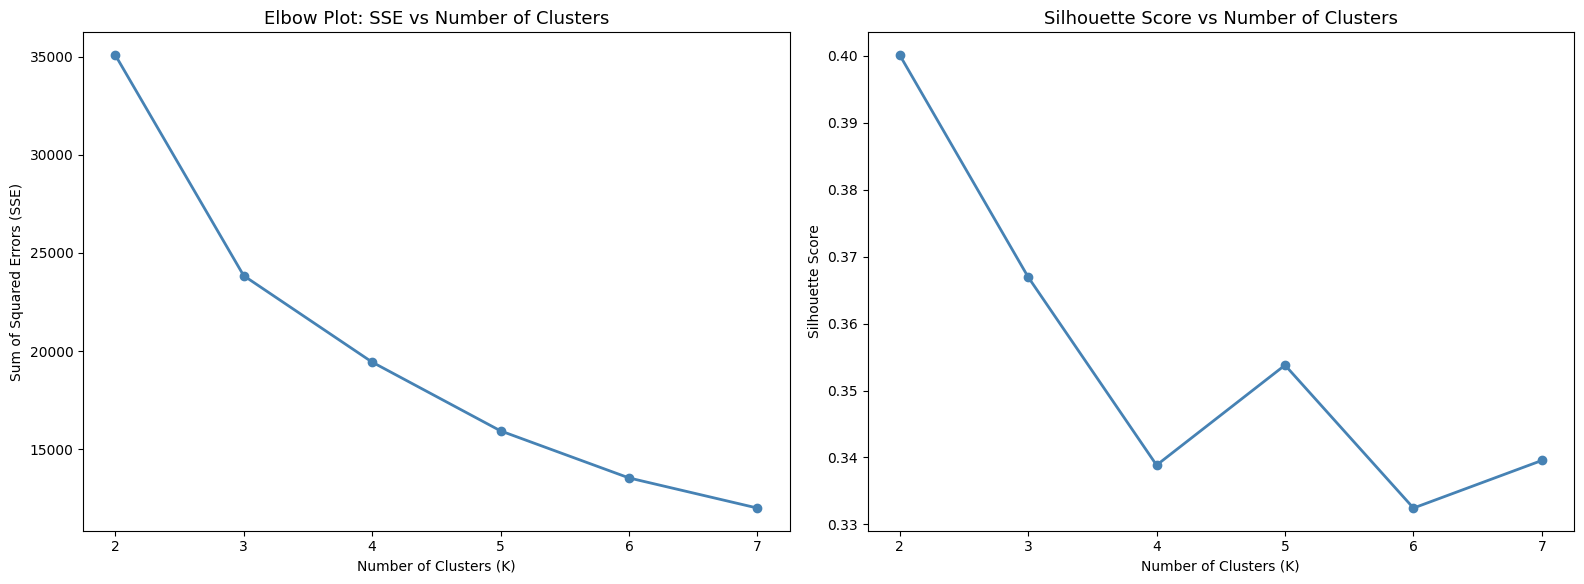


Highest Silhouette Score: K=2 (score=0.4001)


In [10]:
def determine_optimal_k(kmeans_model_paths, pca_np, bucket, s3_client):
    """
    Evaluate KMeans models using Elbow Plot (SSE) and Silhouette Score to
    determine the optimal number of clusters.

    For each model:
        1. Download and extract model artifacts from S3
        2. Load centroids from the model parameters
        3. Calculate SSE (sum of squared distances to nearest centroid)
        4. Calculate Silhouette Score (cluster cohesion vs separation)

    Parameters:
        kmeans_model_paths (list): List of (k, s3_uri) tuples.
        pca_np (np.ndarray): The PCA-transformed data as float32 array.
        bucket (str): The S3 bucket name.
        s3_client: The Boto3 S3 client.

    Returns:
        tuple: (best_k, sse_values, silhouette_values, k_list) where best_k is the
            K with the highest Silhouette Score.
    """
    sse_values = []
    silhouette_values = []
    k_list = []

    for k, model_path in kmeans_model_paths:
        try:
            # Download model artifacts
            local_path = f'/tmp/kmeans-model-k-{k}.tar.gz'
            s3_key = model_path.replace(f's3://{bucket}/', '')
            s3_client.download_file(bucket, s3_key, local_path)

            # Extract model artifacts
            with tarfile.open(local_path) as tar:
                tar.extractall(path=f'/tmp/kmeans-k-{k}', filter='data')

            # Load centroids
            centroids = load_model_array(f'/tmp/kmeans-k-{k}/model_algo-1')

            # Calculate distances from each point to each centroid
            distances = np.sqrt(((pca_np - centroids[:, np.newaxis])**2).sum(axis=2))

            # Determine closest centroid for each data point
            closest_centroids = np.argmin(distances, axis=0)

            # Calculate SSE
            sse = np.sum((pca_np - centroids[closest_centroids])**2)
            sse_values.append(sse)

            # Calculate Silhouette Score
            sil_score = silhouette_score(pca_np, closest_centroids)
            silhouette_values.append(sil_score)

            k_list.append(k)
            print(f"K={k}: SSE={sse:.2f}, Silhouette={sil_score:.4f}")

        except Exception as e:
            print(f"Error processing model for K={k}: {e}")

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Elbow Plot
    sns.set_theme(style='whitegrid')
    axes[0].plot(k_list, sse_values, marker='o', linewidth=2, color='steelblue')
    axes[0].set_title('Elbow Plot: SSE vs Number of Clusters', fontsize=13)
    axes[0].set_xlabel('Number of Clusters (K)')
    axes[0].set_ylabel('Sum of Squared Errors (SSE)')
    axes[0].set_xticks(k_list)

    # Silhouette Score Plot
    axes[1].plot(k_list, silhouette_values, marker='o', linewidth=2, color='steelblue')
    axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=13)
    axes[1].set_xlabel('Number of Clusters (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_xticks(k_list)

    plt.tight_layout()
    plt.show()

    # Recommend best K based on highest silhouette score
    best_idx = np.argmax(silhouette_values)
    print(f"\nHighest Silhouette Score: K={k_list[best_idx]} (score={silhouette_values[best_idx]:.4f})")

    return k_list[best_idx], sse_values, silhouette_values, k_list


best_k, sse_values, silhouette_values, k_list = determine_optimal_k(
    kmeans_model_paths, pca_np, bucket, s3_client
)

## What to Look For: Choosing the Best K

You now have two tools to help you pick the optimal number of clusters:

1. **Elbow Plot (SSE):** Look for the "elbow," the point where the line bends and adding more clusters stops reducing SSE significantly. The elbow is not always obvious, so use it as a rough guide rather than a definitive answer.

2. **Silhouette Score:** Higher is better. This measures how well-separated the clusters are. The code automatically selects the K with the highest Silhouette Score and stores it in `best_k`.

**What if they disagree?** They often do. If the Elbow Plot suggests K=3 but the Silhouette Score favors K=4, consider both and think about which produces more meaningful business segments. There is no single "correct" answer in unsupervised learning.

**Override:** If you want to try a different K, you can change `best_k` in the code cell below before running the HPT step. Otherwise, it uses the Silhouette Score recommendation automatically.

# STEP 11: TRAIN KMEANS MODEL WITH HYPERPARAMETER TUNING

In STEP 10, we used the Elbow Plot and Silhouette Score to determine the optimal number of clusters (`best_k`). Now we use **SageMaker Automatic Model Tuning (Hyperparameter Tuning)** to optimize the KMeans *training hyperparameters* for that K value.

This is an important distinction: STEP 10 answered **"how many clusters?"** while this step answers **"what training settings produce the tightest clusters for that K?"**

SageMaker runs multiple training jobs with different hyperparameter combinations and identifies the best configuration using a Bayesian optimization strategy.

**What is about to happen:**
- Split the PCA-reduced data into **train (80%)** and **test (20%)** sets
- Configure a KMeans estimator with K fixed to `best_k` from STEP 10
- Define hyperparameter ranges for SageMaker to search
- Launch a tuning job with 10 total training jobs (2 running in parallel at a time)

**Fixed hyperparameter:**
- `k` = `best_k` (determined by Silhouette Score in STEP 10)

**Tuned hyperparameters:**

| Hyperparameter | Type | Range | Why Tune It? |
|----------------|------|-------|-------------|
| `mini_batch_size` | Integer | 100 - 2,000 | Controls how many data points are used in each training iteration. Smaller batches can find better local optima but take longer. |
| `extra_center_factor` | Integer | 2 - 10 | SageMaker initially creates K x extra_center_factor centers, then reduces to K. Higher values explore more of the data space during initialization. |
| `epochs` | Integer | 1 - 10 | Number of passes through the training data. More epochs allow the algorithm to refine centroids further. |
| `init_method` | Categorical | random, kmeans++ | How initial cluster centers are chosen. kmeans++ spreads centers apart, random picks randomly. |

**Objective metric:** `test:msd` (Mean Squared Distance) - measures the average squared distance from each test point to its nearest cluster center. **Lower is better** (tighter clusters).

**AWS cost note:** This step launches 10 training jobs (2 at a time). Each uses `ml.m5.large` and completes in under a minute, keeping costs minimal.

In [11]:
def train_kmeans_with_hpt(pca_np, num_pca_components, k, sagemaker_session, role, bucket, prefix, sagemaker_client):
    """
    Train KMeans using SageMaker Hyperparameter Tuning.

    Splits the PCA-reduced data into train/test, creates a KMeans estimator
    with the given K, defines hyperparameter ranges, and launches a tuning job.

    Parameters:
        pca_np (np.ndarray): PCA-transformed data as float32 array.
        num_pca_components (int): Number of PCA components (feature_dim for KMeans).
        k (int): Number of clusters (determined in STEP 10 via Silhouette Score).
        sagemaker_session: The SageMaker session.
        role (str): The IAM role ARN.
        bucket (str): The S3 bucket name.
        prefix (str): The S3 prefix.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        HyperparameterTuner: The completed tuner object.
    """
    from sagemaker.tuner import HyperparameterTuner, IntegerParameter, CategoricalParameter
    from sklearn.model_selection import train_test_split

    # Split PCA data into train (80%) and test (20%) for the tuning metric
    train_data, test_data = train_test_split(pca_np, test_size=0.2, random_state=42)
    train_data = train_data.astype('float32')
    test_data = test_data.astype('float32')

    print(f"Train set: {train_data.shape[0]} samples")
    print(f"Test set:  {test_data.shape[0]} samples")
    print(f"K:         {k} clusters (from STEP 10)")
    print(f"Features:  {num_pca_components} PCA components\n")

    # Create the KMeans estimator with fixed hyperparameters
    output_path = f's3://{bucket}/{prefix}/kmeans-hpt/output'

    kmeans = sagemaker.KMeans(
        sagemaker_session=sagemaker_session,
        role=role,
        instance_count=1,
        instance_type='ml.m5.large',
        k=k,
        output_path=output_path,
        feature_dim=num_pca_components
    )

    # Define hyperparameter ranges to tune
    hyperparameter_ranges = {
        'mini_batch_size': IntegerParameter(100, 2000),
        'extra_center_factor': IntegerParameter(2, 10),
        'epochs': IntegerParameter(1, 10),
        'init_method': CategoricalParameter(['random', 'kmeans++']),
    }

    # Create the Hyperparameter Tuner
    tuner = HyperparameterTuner(
        estimator=kmeans,
        objective_metric_name='test:msd',
        hyperparameter_ranges=hyperparameter_ranges,
        objective_type='Minimize',
        max_jobs=10,
        max_parallel_jobs=2,
    )

    # Create RecordSet objects for train and test channels
    train_records = kmeans.record_set(train_data, channel='train')
    test_records = kmeans.record_set(test_data, channel='test')

    # Launch the tuning job
    print("Launching hyperparameter tuning job...")
    print("This will run 10 training jobs (2 at a time). Estimated time: 10-15 minutes.\n")
    tuner.fit([train_records, test_records])
    print("\nHyperparameter tuning job complete!")

    return tuner


# pca_np was already computed in STEP 8 (Transform Data Using PCA)

print(f"Using best_k = {best_k} from STEP 10 (Silhouette Score analysis)")
print()

tuner = train_kmeans_with_hpt(
    pca_np, num_pca_components, best_k,
    sagemaker_session, role, bucket, prefix,
    sagemaker_client
)

Using best_k = 2 from STEP 10 (Silhouette Score analysis)

Train set: 8101 samples
Test set:  2026 samples
K:         2 clusters (from STEP 10)
Features:  2 PCA components



INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating hyperparameter tuning job with name: kmeans-260321-0252


Launching hyperparameter tuning job...
This will run 10 training jobs (2 at a time). Estimated time: 10-15 minutes.

.......................................................................................!

Hyperparameter tuning job complete!


## What to Look For

You should see the tuning job launch and complete with 10 training jobs. SageMaker uses **Bayesian optimization** to intelligently choose hyperparameter combinations, learning from earlier jobs to focus on promising regions of the search space.

**While it runs:** You can monitor progress in the AWS Console under SageMaker > Training > Hyperparameter tuning jobs.

**When it finishes:** The tuner automatically identifies the best training job (lowest test:msd) for the K value determined in STEP 9. We will analyze the results in the next step.

# STEP 12: ANALYZE TUNING RESULTS

Now we examine what the tuner found. This step retrieves the best hyperparameters and displays the full tuning analytics so you can see how different configurations performed.

**What is about to happen:**
- Retrieve the best training job name and its hyperparameters
- Display a comparison table of all 10 training jobs sorted by test:msd
- Show the best hyperparameter values that minimized mean squared distance

In [12]:
def analyze_tuning_results(tuner, sagemaker_client):
    """
    Retrieve and display the results of the hyperparameter tuning job.

    Shows the best hyperparameters and a comparison table of all training jobs.

    Parameters:
        tuner: The completed HyperparameterTuner.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        dict: The best training job description including model artifact S3 URI.
    """
    # Get the tuning job name
    tuning_job_name = tuner.latest_tuning_job.name
    print(f"Tuning Job: {tuning_job_name}\n")

    # Get tuning job results
    tuning_results = sagemaker_client.describe_hyper_parameter_tuning_job(
        HyperParameterTuningJobName=tuning_job_name
    )

    # Best training job
    best_job = tuning_results['BestTrainingJob']
    best_job_name = best_job['TrainingJobName']
    best_metric = best_job['FinalHyperParameterTuningJobObjectiveMetric']['Value']

    print(f"Best Training Job: {best_job_name}")
    print(f"Best test:msd: {best_metric:.6f}\n")

    # Display best hyperparameters
    best_hp = best_job['TunedHyperParameters']
    print("Best Hyperparameters:")
    print(f"  mini_batch_size:    {best_hp.get('mini_batch_size', 'N/A')}")
    print(f"  extra_center_factor: {best_hp.get('extra_center_factor', 'N/A')}")
    print(f"  epochs:             {best_hp.get('epochs', 'N/A')}")
    print(f"  init_method:        {best_hp.get('init_method', 'N/A')}\n")

    # Get all training jobs for comparison
    all_jobs = sagemaker_client.list_training_jobs_for_hyper_parameter_tuning_job(
        HyperParameterTuningJobName=tuning_job_name,
        SortBy='FinalObjectiveMetricValue',
        SortOrder='Ascending'
    )['TrainingJobSummaries']

    # Build comparison table
    rows = []
    for i, job in enumerate(all_jobs):
        job_hp = job.get('TunedHyperParameters', {})
        metric_val = job.get('FinalHyperParameterTuningJobObjectiveMetric', {}).get('Value', 'N/A')
        status = job.get('TrainingJobStatus', 'Unknown')
        rows.append({
            'Rank': i + 1,
            'mini_batch_size': job_hp.get('mini_batch_size', 'N/A'),
            'extra_center_factor': job_hp.get('extra_center_factor', 'N/A'),
            'epochs': job_hp.get('epochs', 'N/A'),
            'init_method': job_hp.get('init_method', 'N/A'),
            'test:msd': f"{metric_val:.6f}" if isinstance(metric_val, float) else metric_val,
            'Status': status
        })

    results_df = pd.DataFrame(rows)
    print("All Training Jobs (sorted by test:msd, lower is better):")
    print(tabulate(results_df.values.tolist(), headers=results_df.columns.tolist(), tablefmt='grid'))

    # Get best model artifact URI
    best_job_desc = sagemaker_client.describe_training_job(TrainingJobName=best_job_name)
    best_model_uri = best_job_desc['ModelArtifacts']['S3ModelArtifacts']
    print(f"\nBest model artifact: {best_model_uri}")

    return best_job_desc


best_job_desc = analyze_tuning_results(tuner, sagemaker_client)
best_model_uri = best_job_desc['ModelArtifacts']['S3ModelArtifacts']

# Store as a list for compatibility with the visualization function
hpt_model_paths = [(best_k, best_model_uri)]

Tuning Job: kmeans-260321-0252

Best Training Job: kmeans-260321-0252-005-a21a0005
Best test:msd: 3.402957

Best Hyperparameters:
  mini_batch_size:    995
  extra_center_factor: 3
  epochs:             2
  init_method:        random

All Training Jobs (sorted by test:msd, lower is better):
+--------+-------------------+-----------------------+----------+---------------+------------+-----------+
|   Rank |   mini_batch_size |   extra_center_factor |   epochs | init_method   |   test:msd | Status    |
+========+===================+=======================+==========+===============+============+===========+
|      1 |               995 |                     3 |        2 | random        |    3.40296 | Completed |
+--------+-------------------+-----------------------+----------+---------------+------------+-----------+
|      2 |              1064 |                    10 |        7 | random        |    3.41763 | Completed |
+--------+-------------------+-----------------------+----------+-

## What to Look For

**Best hyperparameters:** Look at which combination of mini_batch_size, extra_center_factor, epochs, and init_method produced the lowest test:msd (mean squared distance). Lower MSD means data points are closer to their assigned cluster centers on average.

**Comparison table:** Notice how different hyperparameter combinations affect the MSD. Some patterns to look for:
- Does `kmeans++` initialization consistently outperform `random`?
- Do more epochs always help, or is there diminishing returns?
- How sensitive is the result to `mini_batch_size`?

**Bayesian optimization:** The tuner does not search randomly. It uses results from earlier jobs to focus on promising regions. You may notice that later jobs (higher rank numbers) tend to have worse scores, because the tuner already found good values early.

**Compare with base notebook:** In the base Demo notebook, you manually searched K values. Here, K was determined automatically in STEP 10, and the tuner optimized the training configuration for that K. Both approaches are valid and complementary.

# STEP 13: VISUALIZE CLUSTERS

This is the payoff of the entire notebook. We visualize the cluster assignments from the best tuned model and check whether they correspond to meaningful housing price tiers.

**What is about to happen:**
- Download the best model's centroids from S3
- Assign each data point to its nearest centroid
- **Plot 1 (left):** Scatter plot of all homes in PCA space, colored by cluster assignment with centroids marked as black X
- **Plot 2 (right):** Same scatter plot, but colored by SalePrice (green = expensive, red = cheap). This is the validation: we never told the model about SalePrice, so if the color gradient aligns with the clusters, it means the algorithm found real structure.
- **Plot 3:** Box plot showing SalePrice distribution within each cluster
- **Cluster profile table:** Average SalePrice, quality, size, and age per cluster with plain-English descriptions

**Note:** The visualization uses the **full dataset** (not just the training split from STEP 8). The train/test split was only needed for the tuning metric. For visualization and profiling, we want to see all data points.

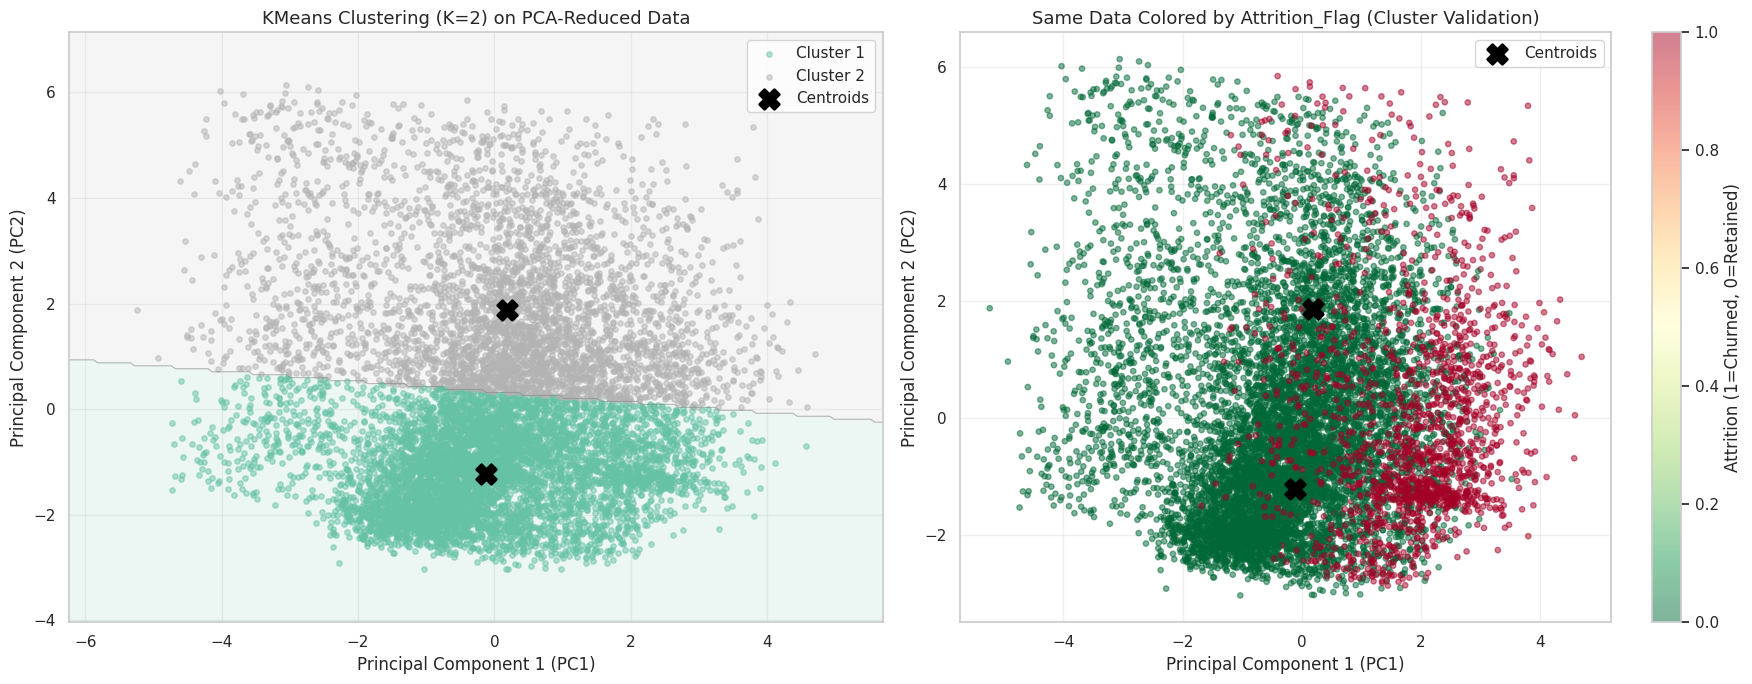

/tmp/ipykernel_32135/60242443.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_df, x='Cluster', y='Attrition',


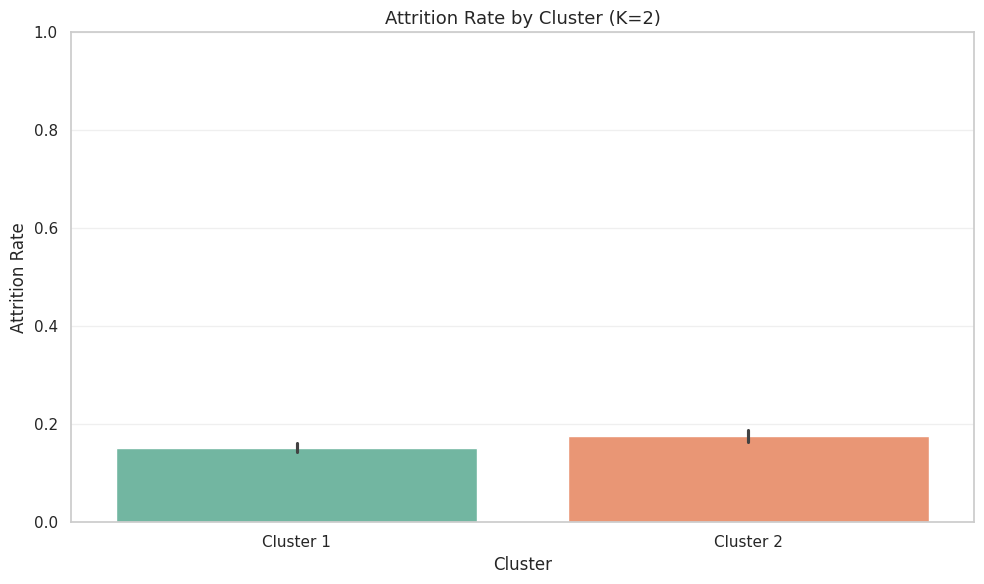


Cluster Summary (K=2):
Cluster      Count  Attrition %      Churned    Retained
---------  -------  -------------  ---------  ----------
Cluster 1     6395  15.2%                971        5424
Cluster 2     3732  17.6%                656        3076

Cluster Profiles (sorted by attrition rate):
Cluster      Count  Attrition Rate      Avg Customer_Age  Avg Credit_Limit    Avg Total_Trans_Amt      Avg Months_on_book    Avg Total_Relationship_Count  Description
---------  -------  ----------------  ------------------  ------------------  ---------------------  --------------------  ------------------------------  ------------------------------------------------------------------------
Cluster 1     6395  15.2%                             46  $3,718              $4,013                                   36                               4  low-churn, mid-age customers, lower credit limits, established customers
Cluster 2     3732  17.6%                             46  $17,052             $

In [15]:
def visualize_clusters(pca_np, kmeans_model_paths, attrition_flag, best_k, bucket, s3_client, df_features=None):
    """
    Visualize the cluster assignments from the optimal KMeans model.
    Creates three visualizations:
        1. Clusters colored by cluster assignment with centroids
        2. Data points colored by Attrition_Flag (cluster validation)
        3. Box plot of cluster characteristics

    Also generates a cluster profile table and plain-English descriptions
    based on attrition rate and customer characteristics per cluster.

    Parameters:
        pca_np (np.ndarray): The PCA-transformed data.
        kmeans_model_paths (list): List of (k, s3_uri) tuples.
        attrition_flag (pd.Series): The held-out Attrition_Flag values.
        best_k (int): The optimal number of clusters.
        bucket (str): The S3 bucket name.
        s3_client: The Boto3 S3 client.
        df_features (pd.DataFrame): The preprocessed feature DataFrame for profiling.

    Returns:
        tuple: (centroids, closest_centroids, cluster_profiles)
    """
    # Download and extract the best model
    best_model_path = next(path for k, path in kmeans_model_paths if k == best_k)
    local_path = f'/tmp/kmeans-best-k-{best_k}.tar.gz'
    s3_key = best_model_path.replace(f's3://{bucket}/', '')
    s3_client.download_file(bucket, s3_key, local_path)

    with tarfile.open(local_path) as tar:
        tar.extractall(path=f'/tmp/kmeans-best-k-{best_k}', filter='data')

    # Load centroids
    centroids = load_model_array(f'/tmp/kmeans-best-k-{best_k}/model_algo-1')

    # Calculate cluster assignments
    distances = np.sqrt(((pca_np - centroids[:, np.newaxis])**2).sum(axis=2))
    closest_centroids = np.argmin(distances, axis=0)

    # --- Plot 1: Clusters with centroids ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    colors = plt.cm.Set2(np.linspace(0, 1, best_k))

    # --- Decision boundary background (Voronoi regions) ---
    x_min, x_max = pca_np[:, 0].min() - 1, pca_np[:, 0].max() + 1
    y_min, y_max = pca_np[:, 1].min() - 1, pca_np[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()].astype('float32')

    # Assign each grid point to its nearest centroid
    grid_distances = np.sqrt(((grid_points[:, np.newaxis, :] -
                               centroids[np.newaxis, :, :])**2).sum(axis=2))
    grid_labels = np.argmin(grid_distances, axis=1).reshape(xx.shape)

    # Shade each cluster's territory with low alpha so data points remain visible
    axes[0].contourf(xx, yy, grid_labels, levels=np.arange(best_k + 1) - 0.5,
                     colors=colors, alpha=0.12)
    axes[0].contour(xx, yy, grid_labels, levels=np.arange(best_k + 1) - 0.5,
                    colors='gray', linewidths=0.8, alpha=0.5)

    for i in range(best_k):
        mask = closest_centroids == i
        axes[0].scatter(pca_np[mask, 0], pca_np[mask, 1],
                       c=[colors[i]], alpha=0.5, s=15, label=f'Cluster {i+1}')

    # Plot centroids as black X markers
    axes[0].scatter(centroids[:, 0], centroids[:, 1],
                   c='black', marker='X', s=200, linewidths=2, label='Centroids')
    axes[0].set_title(f'KMeans Clustering (K={best_k}) on PCA-Reduced Data', fontsize=13)
    axes[0].set_xlabel('Principal Component 1 (PC1)')
    axes[0].set_ylabel('Principal Component 2 (PC2)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- Plot 2: Color by Attrition_Flag (cluster validation) ---
    attrition_numeric = (attrition_flag == 'Attrited Customer').astype(int)
    scatter = axes[1].scatter(pca_np[:, 0], pca_np[:, 1],
                             c=attrition_numeric, cmap='RdYlGn_r', alpha=0.5, s=15)
    axes[1].scatter(centroids[:, 0], centroids[:, 1],
                   c='black', marker='X', s=200, linewidths=2, label='Centroids')
    cbar = plt.colorbar(scatter, ax=axes[1])
    cbar.set_label('Attrition (1=Churned, 0=Retained)')
    axes[1].set_title('Same Data Colored by Attrition_Flag (Cluster Validation)', fontsize=13)
    axes[1].set_xlabel('Principal Component 1 (PC1)')
    axes[1].set_ylabel('Principal Component 2 (PC2)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Alternative Plot 3: Attrition rate by cluster ---
    cluster_labels = [f'Cluster {c+1}' for c in closest_centroids]
    churn_df = pd.DataFrame({
        'Cluster': cluster_labels,
        'Attrition': (attrition_flag == 'Attrited Customer').astype(int)
    })

    plt.figure(figsize=(10, 6))
    churn_rate_by_cluster = churn_df.groupby('Cluster')['Attrition'].agg(['sum', 'count'])
    churn_rate_by_cluster['Rate'] = churn_rate_by_cluster['sum'] / churn_rate_by_cluster['count']
    
    cluster_order = (churn_rate_by_cluster.sort_values('Rate').index.tolist())
    
    sns.barplot(data=churn_df, x='Cluster', y='Attrition', 
                order=cluster_order, palette='Set2', estimator=lambda x: (x==1).sum()/len(x))
    plt.title(f'Attrition Rate by Cluster (K={best_k})', fontsize=13)
    plt.xlabel('Cluster')
    plt.ylabel('Attrition Rate')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # --- Summary table: cluster sizes and attrition rate ---
    print(f"\nCluster Summary (K={best_k}):")
    summary_data = []
    for i in range(best_k):
        mask = closest_centroids == i
        cluster_attrition = (attrition_flag[mask] == 'Attrited Customer').astype(int)
        summary_data.append([
            f'Cluster {i+1}',
            int(mask.sum()),
            f'{cluster_attrition.mean()*100:.1f}%',
            int(cluster_attrition.sum()),
            int((~cluster_attrition.astype(bool)).sum())
        ])

    headers = ['Cluster', 'Count', 'Attrition %', 'Churned', 'Retained']
    print(tabulate(summary_data, headers=headers))

    # --- Cluster profiling with original features ---
    cluster_profiles = None
    profile_features = ['Customer_Age', 'Credit_Limit', 'Total_Trans_Amt', 'Months_on_book', 'Total_Relationship_Count']

    if df_features is not None:
        available_features = [f for f in profile_features if f in df_features.columns]

        if available_features:
            profile_data = []
            for i in range(best_k):
                mask = closest_centroids == i
                cluster_attrition = (attrition_flag[mask] == 'Attrited Customer').astype(int)
                row = {
                    'Cluster': i + 1,
                    'Count': int(mask.sum()),
                    'Attrition_Rate': cluster_attrition.mean()
                }
                for feat in available_features:
                    row[f'Avg_{feat}'] = df_features.loc[mask, feat].mean()
                profile_data.append(row)

            cluster_profiles = pd.DataFrame(profile_data)

            # Sort clusters by attrition rate
            cluster_profiles = cluster_profiles.sort_values('Attrition_Rate').reset_index(drop=True)

            # Generate descriptions based on attrition and characteristics
            descriptions = []
            for idx, row in cluster_profiles.iterrows():
                attrition_pct = row['Attrition_Rate'] * 100
                
                if attrition_pct < 20:
                    churn_label = 'low-churn'
                elif attrition_pct < 40:
                    churn_label = 'moderate-churn'
                else:
                    churn_label = 'high-churn'
                
                age = row.get('Avg_Customer_Age', None)
                age_label = ''
                if age is not None:
                    if age < 35:
                        age_label = 'younger customers'
                    elif age < 50:
                        age_label = 'mid-age customers'
                    else:
                        age_label = 'older customers'
                
                credit = row.get('Avg_Credit_Limit', None)
                credit_label = ''
                if credit is not None:
                    if credit < 5000:
                        credit_label = 'lower credit limits'
                    elif credit < 10000:
                        credit_label = 'mid-range credit limits'
                    else:
                        credit_label = 'high credit limits'
                
                months = row.get('Avg_Months_on_book', None)
                tenure_label = ''
                if months is not None:
                    if months < 12:
                        tenure_label = 'new customers'
                    elif months < 36:
                        tenure_label = 'established customers'
                    else:
                        tenure_label = 'long-term customers'
                
                parts = [churn_label]
                if age_label:
                    parts.append(age_label)
                if credit_label:
                    parts.append(credit_label)
                if tenure_label:
                    parts.append(tenure_label)
                
                descriptions.append(', '.join(parts))

            cluster_profiles['Description'] = descriptions

            # Display cluster profile table
            print(f"\nCluster Profiles (sorted by attrition rate):")
            col_labels = ['Cluster', 'Count', 'Attrition Rate']
            for feat in available_features:
                col_labels.append(f'Avg {feat}')
            col_labels.append('Description')

            profile_table = []
            for _, row in cluster_profiles.iterrows():
                table_row = [
                    f'Cluster {int(row["Cluster"])}',
                    int(row['Count']),
                    f'{row["Attrition_Rate"]*100:.1f}%'
                ]
                for feat in available_features:
                    col_key = f'Avg_{feat}'
                    val = row[col_key]
                    if feat in ('Credit_Limit', 'Total_Trans_Amt'):
                        table_row.append(f'${val:,.0f}')
                    else:
                        table_row.append(f'{val:.0f}')
                table_row.append(row['Description'])
                profile_table.append(table_row)

            print(tabulate(profile_table, headers=col_labels))

            # Print descriptions separately for emphasis
            print(f"\nCluster Descriptions:")
            for _, row in cluster_profiles.iterrows():
                print(f"  Cluster {int(row['Cluster'])}: {row['Description']}")

    return centroids, closest_centroids, cluster_profiles


# best_k was determined automatically in STEP 10 using the highest Silhouette Score.
# To override, uncomment the line below and set your preferred value:
# best_k = 4
attrition_flag = df['Attrition_Flag'].copy()
centroids, cluster_assignments, cluster_profiles = visualize_clusters(
    pca_np, kmeans_model_paths, attrition_flag, best_k, bucket, s3_client, df_features
)

## What to Look For

**Plot 1 (Clusters):** Are the clusters well-separated or overlapping? With ~200 sparse features, you may see more overlap between clusters because PCA captured less of the total variance in just 2 components.

**Plot 2 (SalePrice validation):** This is the key test. The model never saw SalePrice, so if the color gradient (green = expensive, red = cheap) aligns with the cluster boundaries, it means the algorithm found real housing market segments. Look for whether expensive homes (green) cluster together and cheaper homes (red) cluster separately.

**Plot 3 (Box plot):** Each box shows the price distribution within a cluster. Look for:
- **Separation between medians:** Different clusters should have noticeably different median prices
- **Box overlap:** Some overlap is normal, but the medians should follow a clear progression

**Cluster Profiles table:** Read the plain-English descriptions. Do the clusters make intuitive business sense? For example, you might see segments like "budget tier, lower quality, smaller homes, older construction" vs. "premium tier, high quality, spacious homes, recent construction."

**Compare with Demo 2:** The cluster separation and SalePrice alignment may be cleaner in Demo 2 because the dense encoding gives PCA better signal.

## Business Application: Turning Clusters into Strategy

The cluster profiles above are not just a technical exercise. In a real business context, these segments would drive concrete decisions:

**Customer Segmentation and Targeted Marketing:**
- Each cluster represents a distinct housing market segment with different price points, quality levels, and home characteristics
- A real estate company could tailor marketing materials, listing descriptions, and advertising channels to each segment
- For example, "Premium tier" homes might be marketed through luxury channels with professional staging, while "Budget tier" homes might emphasize value and potential

**Pricing Strategy:**
- New listings can be run through the prediction pipeline to identify which segment they belong to, providing an instant price range estimate
- Homes that fall near cluster boundaries may represent opportunities for repositioning through renovations

**Inventory and Investment Analysis:**
- Developers can identify which segments are underserved in a market
- Investors can target specific clusters based on their risk and return preferences

**Key Insight:** None of this required telling the model about price. The algorithm discovered these segments purely from physical characteristics, quality ratings, and location features. The fact that the clusters align with price tiers validates that the model found real market structure, not just random groupings.

**Compare with Demo 2:** Demo 2 uses optimized encoding (~74 dense features instead of ~200 sparse features), which typically produces cleaner cluster separation and more actionable segments.

# STEP 14: DEPLOY BEST KMEANS MODEL TO ENDPOINT

Deploy the best KMeans model from the tuning job to a real-time SageMaker endpoint for predictions. This allows us to send new PCA-transformed data points and receive cluster assignments.

**What is about to happen:**
- Delete any existing endpoint with the same name (to avoid conflicts)
- Create a SageMaker Model object from the best tuned model artifacts
- Deploy it to an `ml.m5.large` instance as a real-time endpoint
- This may take 3-5 minutes while AWS provisions the instance

In [ ]:
def delete_endpoint_and_config(endpoint_name, sagemaker_client):
    """
    Delete a SageMaker endpoint and its endpoint configuration if they exist.
    Polls until both resources are fully deleted.

    This function is defined here in the deploy step and reused in the
    cleanup step (STEP 16) without duplication.

    Parameters:
        endpoint_name (str): The name of the endpoint to delete.
        sagemaker_client: The Boto3 SageMaker client.
    """
    # Delete endpoint if it exists
    try:
        sagemaker_client.describe_endpoint(EndpointName=endpoint_name)
        print(f'Deleting endpoint: {endpoint_name}')
        sagemaker_client.delete_endpoint(EndpointName=endpoint_name)
    except ClientError as e:
        if e.response['Error']['Code'] == 'ValidationException' and 'Could not find' in e.response['Error']['Message']:
            print(f'Endpoint "{endpoint_name}" does not exist.')
        else:
            raise

    # Delete endpoint config if it exists
    try:
        sagemaker_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
        print(f'Deleting endpoint configuration: {endpoint_name}')
        sagemaker_client.delete_endpoint_config(EndpointConfigName=endpoint_name)
    except ClientError as e:
        if e.response['Error']['Code'] == 'ValidationException' and 'Could not find' in e.response['Error']['Message']:
            print(f'Endpoint config "{endpoint_name}" does not exist.')
        else:
            raise

    # Poll for deletion
    print('Waiting for resources to be deleted...')
    for _ in range(30):
        endpoint_exists = True
        config_exists = True

        try:
            sagemaker_client.describe_endpoint(EndpointName=endpoint_name)
        except ClientError:
            endpoint_exists = False

        try:
            sagemaker_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
        except ClientError:
            config_exists = False

        if not endpoint_exists and not config_exists:
            print('Endpoint and endpoint config fully deleted.')
            break

        time.sleep(10)
    else:
        print('Warning: resources may not be fully deleted after 30 checks.')


def deploy_best_tuned_model(best_model_uri, best_k, endpoint_name, kmeans_image_uri, role, sagemaker_session, sagemaker_client):
    """
    Deploy the best model from the tuning job to a SageMaker endpoint.

    Parameters:
        best_model_uri (str): S3 URI of the best model artifacts.
        best_k (int): The number of clusters.
        endpoint_name (str): The name for the endpoint.
        kmeans_image_uri (str): The KMeans Docker image URI.
        role (str): The IAM role ARN.
        sagemaker_session: The SageMaker session.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        Predictor: The SageMaker Predictor object for making predictions.
    """
    # Delete any existing endpoint first
    delete_endpoint_and_config(endpoint_name, sagemaker_client)

    # Create a SageMaker Model object from the best tuned model
    best_model = Model(
        model_data=best_model_uri,
        image_uri=kmeans_image_uri,
        role=role,
        sagemaker_session=sagemaker_session
    )

    # Deploy the model to an endpoint
    print(f'\nDeploying best tuned KMeans model (K={best_k}) to endpoint: {endpoint_name}')
    print('This may take several minutes...')

    predictor = best_model.deploy(
        endpoint_name=endpoint_name,
        initial_instance_count=1,
        instance_type='ml.m5.large'
    )

    print(f'\nEndpoint "{endpoint_name}" deployed successfully!')
    return predictor


endpoint_name = 'ames-pca-kmeans-demo1-hpt'
predictor = deploy_best_tuned_model(
    best_model_uri, best_k, endpoint_name,
    kmeans_image_uri, role, sagemaker_session, sagemaker_client
)

# Configure the predictor serializer for CSV input
predictor = Predictor(endpoint_name=endpoint_name, serializer=CSVSerializer())

## What to Look For

You should see the endpoint being created and eventually a success message. The endpoint name is `ames-pca-kmeans-demo1-hpt`.

**Important:** The endpoint will continue incurring charges until you delete it in STEP 16. Do not skip the cleanup step.

# STEP 15: INTERACTIVE PREDICTION

This step demonstrates the full real-world ML pipeline: a user enters raw housing feature values (Overall Quality, Living Area, etc.), and the code applies the same preprocessing, standardization, and PCA transformation before sending the result to the KMeans endpoint.

**What is about to happen:**
- First, three pre-built example homes run automatically to show how different homes land in different clusters
- Then, you will be prompted to enter 5 key housing features (quality, size, year, basement, garage)
- All other features are filled with median values from the training data
- The code applies: standardization (StandardScaler) then PCA transformation then KMeans prediction
- The result shows which cluster the home belongs to, along with the cluster profile

**The automatic examples include:**
- A luxury home (Quality=9, 3,000 sq ft, built 2010)
- A starter home (Quality=5, 900 sq ft, built 1975)
- A fixer-upper (Quality=3, 1,100 sq ft, built 1950)

**Then try your own scenarios:**
- Your dream home: enter whatever values you like!

Type `quit` at any prompt to exit.

In [13]:
def interactive_prediction(predictor, scaler, pca_components_matrix, df_features, feature_names, cluster_profiles=None):
    """
    Accept user input for key housing features, apply the full preprocessing +
    standardization + PCA pipeline, then send to the KMeans endpoint for cluster
    assignment. If cluster profiles are provided, display the profile for the
    predicted cluster so the user understands what the cluster means.

    The user enters values for a few key features. All other features are filled
    with the median values from the training data, ensuring the input vector has
    the correct number of features for the pipeline.

    Parameters:
        predictor: The SageMaker Predictor for the KMeans endpoint.
        scaler (StandardScaler): The fitted scaler from STEP 5.
        pca_components_matrix (np.ndarray): The PCA transformation matrix from STEP 8.
        df_features (pd.DataFrame): The preprocessed feature DataFrame for defaults.
        feature_names (list): The list of feature column names.
        cluster_profiles (pd.DataFrame): Optional cluster profile data from STEP 13.
    """
    # Define the key features the user will enter
    # These are the most intuitive housing features for students to understand
    user_features = {
        'Overall Qual': ('Overall Quality (1-10)', 1, 10),
        'Gr Liv Area': ('Above-Ground Living Area (sq ft)', 300, 6000),
        'Year Built': ('Year Built (e.g. 1990)', 1870, 2025),
        'Total Bsmt SF': ('Total Basement Area (sq ft, 0 if none)', 0, 6000),
        'Garage Area': ('Garage Area (sq ft, 0 if none)', 0, 1500)
    }

    # Compute median defaults for all features
    median_defaults = df_features.median()

    print("PCA + KMeans Cluster Prediction")
    print("Enter housing features for a prediction, or type 'quit' to exit.")
    print(f"(All other features will use training data median values)\n")


    # --- Run pre-built example predictions automatically ---
    example_homes = [
        {'name': 'Luxury Home',   'Overall Qual': 9, 'Gr Liv Area': 3000, 'Year Built': 2010, 'Total Bsmt SF': 2000, 'Garage Area': 800},
        {'name': 'Starter Home',  'Overall Qual': 5, 'Gr Liv Area': 900,  'Year Built': 1975, 'Total Bsmt SF': 600,  'Garage Area': 300},
        {'name': 'Fixer-Upper',   'Overall Qual': 3, 'Gr Liv Area': 1100, 'Year Built': 1950, 'Total Bsmt SF': 500,  'Garage Area': 0},
    ]

    print("=" * 65)
    print("EXAMPLE PREDICTIONS: Three pre-built homes")
    print("=" * 65)

    for example in example_homes:
        # Start with median defaults
        input_data = median_defaults.copy()

        # Override with example values
        for feat, val in example.items():
            if feat != 'name' and feat in input_data.index:
                input_data[feat] = val

        # Apply the same pipeline: standardize -> PCA -> predict
        input_array = input_data.values.reshape(1, -1).astype('float32')
        input_scaled = scaler.transform(input_array).astype('float32')
        input_pca = input_scaled @ pca_components_matrix
        pca_csv = ','.join([str(v) for v in input_pca.flatten()])

        print(f"\n--- {example['name']} ---")
        print(f"  Quality={example['Overall Qual']}, "
              f"Area={example['Gr Liv Area']:,} sq ft, "
              f"Year={example['Year Built']}, "
              f"Basement={example['Total Bsmt SF']:,} sq ft, "
              f"Garage={example['Garage Area']} sq ft")

        try:
            response = predictor.predict(pca_csv)
            response_json = json.loads(response)
            cluster = int(response_json['predictions'][0]['closest_cluster'])
            distance = response_json['predictions'][0]['distance_to_cluster']

            print(f"  Result: Cluster {cluster + 1} (distance: {distance:.4f})")
            print(f"  PCA values: PC1={input_pca[0,0]:.4f}, PC2={input_pca[0,1]:.4f}")

            if cluster_profiles is not None:
                profile = cluster_profiles[cluster_profiles['Cluster'] == cluster + 1]
                if not profile.empty:
                    row = profile.iloc[0]
                    print(f"  Profile: {row['Description']}")
                    print(f"    Avg Sale Price: ${row['Avg_SalePrice']:,.0f}")
        except Exception as e:
            print(f"  Error during prediction: {e}")

    print(f"\n{'=' * 65}")
    print("YOUR TURN: Enter your own housing features below")
    print(f"{'=' * 65}\n")

    while True:
        # Start with median defaults for all features
        input_data = median_defaults.copy()

        # Collect user inputs
        quit_flag = False
        for feature_name, (prompt_text, min_val, max_val) in user_features.items():
            if feature_name not in input_data.index:
                print(f"  (Skipping {feature_name}, not in feature set)")
                continue

            while True:
                user_input = input(f"  {prompt_text}: ").strip()
                if user_input.lower() == 'quit':
                    quit_flag = True
                    break
                try:
                    value = float(user_input)
                    if min_val <= value <= max_val:
                        input_data[feature_name] = value
                        break
                    else:
                        print(f"    Please enter a value between {min_val} and {max_val}.")
                except ValueError:
                    print(f"    Invalid input. Please enter a number.")

            if quit_flag:
                break

        if quit_flag:
            break

        # Convert to NumPy array in the correct feature order
        input_array = input_data.values.reshape(1, -1).astype('float32')

        # Apply the same standardization
        input_scaled = scaler.transform(input_array).astype('float32')

        # Apply the same PCA transformation
        input_pca = input_scaled @ pca_components_matrix

        # Send PCA-transformed values to the KMeans endpoint
        pca_csv = ','.join([str(v) for v in input_pca.flatten()])

        try:
            response = predictor.predict(pca_csv)
            response_json = json.loads(response)
            cluster = int(response_json['predictions'][0]['closest_cluster'])
            distance = response_json['predictions'][0]['distance_to_cluster']

            print(f"\n  Result: This home belongs to Cluster {cluster + 1} (distance to centroid: {distance:.4f})")
            print(f"  PCA values: PC1={input_pca[0,0]:.4f}, PC2={input_pca[0,1]:.4f}")

            # Display cluster profile if available
            if cluster_profiles is not None:
                profile = cluster_profiles[cluster_profiles['Cluster'] == cluster + 1]
                if not profile.empty:
                    row = profile.iloc[0]
                    print(f"\n  Cluster {cluster + 1} Profile: {row['Description']}")
                    print(f"    Avg Sale Price:    ${row['Avg_SalePrice']:,.0f}")
                    if 'Avg_Overall_Qual' in row:
                        print(f"    Avg Overall Qual:  {row['Avg_Overall_Qual']:.1f}")
                    if 'Avg_Gr_Liv_Area' in row:
                        print(f"    Avg Living Area:   {row['Avg_Gr_Liv_Area']:,.0f} sq ft")
                    if 'Avg_Year_Built' in row:
                        print(f"    Avg Year Built:    {row['Avg_Year_Built']:.0f}")
                    if 'Avg_Total_Bsmt_SF' in row:
                        print(f"    Avg Basement Area: {row['Avg_Total_Bsmt_SF']:,.0f} sq ft")
                    if 'Avg_Garage_Area' in row:
                        print(f"    Avg Garage Area:   {row['Avg_Garage_Area']:,.0f} sq ft")
        except Exception as e:
            print(f"\n  Error during prediction: {e}")

        print()  # Blank line before next iteration

    print("\nPrediction program exited.")


interactive_prediction(predictor, scaler, pca_components_matrix, df_features, feature_names, cluster_profiles)


PCA + KMeans Cluster Prediction
Enter housing features for a prediction, or type 'quit' to exit.
(All other features will use training data median values)



  Overall Quality (1-10):  1
  Above-Ground Living Area (sq ft):  3000
  Year Built (e.g. 1990):  2000
  Total Basement Area (sq ft, 0 if none):  800
  Garage Area (sq ft, 0 if none):  300


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



  Result: This home belongs to Cluster 1 (distance to centroid: 2.0757)
  PCA values: PC1=0.7286, PC2=-0.6125

  Cluster 1 Profile: Moderate tier, lower quality, mid-size homes, older construction
    Avg Sale Price:    $139,366
    Avg Overall Qual:  5.3
    Avg Living Area:   1,268 sq ft
    Avg Year Built:    1953
    Avg Basement Area: 949 sq ft
    Avg Garage Area:   412 sq ft



╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:115                                                                                  │
│                                                                                                  │
│   112 │   print("\nPrediction program exited.")                                                  │
│   113                                                                                            │
│   114                                                                                            │
│ ❱ 115 interactive_prediction(predictor, scaler, pca_components_matrix, df_features, feature_na   │
│   116                                                                                            │
│                                                                                                  │
│ in interactive_prediction:49                                                                     │
│                                                                                                  │
│    46 │   │   │   │   continue                                                                   │
│    47 │   │   │                                                                                  │
│    48 │   │   │   while True:                                                                    │
│ ❱  49 │   │   │   │   user_input = input(f"  {prompt_text}: ").strip()                           │
│    50 │   │   │   │   if user_input.lower() == 'quit':                                           │
│    51 │   │   │   │   │   quit_flag = True                                                       │
│    52 │   │   │   │   │   break                                                                  │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/ipykernel/kernelbase.py:1396  │
│ in raw_input                                                                                     │
│                                                                                                  │
│   1393 │   │   if not self._allow_stdin:                                                         │
│   1394 │   │   │   msg = "raw_input was called, but this frontend does not support input reques  │
│   1395 │   │   │   raise StdinNotImplementedError(msg)                                           │
│ ❱ 1396 │   │   return self._input_request(                                                       │
│   1397 │   │   │   str(prompt),                                                                  │
│   1398 │   │   │   self._get_shell_context_var(self._shell_parent_ident),                        │
│   1399 │   │   │   self.get_parent("shell"),                                                     │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/ipykernel/kernelbase.py:1441  │
│ in _input_request                                                                                │
│                                                                                                  │
│   1438 │   │   │   except KeyboardInterrupt:                                                     │
│   1439 │   │   │   │   # re-raise KeyboardInterrupt, to truncate traceback                       │
│   1440 │   │   │   │   msg = "Interrupted by user"                                               │
│ ❱ 1441 │   │   │   │   raise KeyboardInterrupt(msg) from None                                    │
│   1442 │   │   │   except Exception:                                                             │
│   1443 │   │   │   │   self.log.warning("Invalid Message:", exc_info=True)                       │
│   1444                                                     

# STEP 16: CLEANUP

Delete the SageMaker endpoint and endpoint configuration to stop incurring charges. This reuses the `delete_endpoint_and_config` function defined in STEP 14.

**Important:** SageMaker endpoints charge by the hour. Always run this cell when you are done to avoid unexpected costs on your AWS account.

In [ ]:
# ⚠️ AWS COST WARNING ⚠️
# SageMaker endpoints incur charges as long as they are running.
# Make sure to delete your endpoint when you are done to avoid unexpected costs.

response = input("Are you sure you want to delete the endpoint? (yes/no): ").strip().lower()
if response == 'yes':
    delete_endpoint_and_config(endpoint_name, sagemaker_client)
    print("\nEndpoint cleanup complete.")
else:
    print("\nEndpoint was NOT deleted. Remember to delete it later to avoid charges.")